### Housekeeping

In [2]:
%reset -f

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({'font.size': 16})
import seaborn as sns
import matplotlib.dates as mdates
import nrarfcn as nr

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Map plotting imports
import geopandas as gpd
from bokeh.plotting import figure, show#, output_notebook
# output_notebook()
from bokeh.models import ColumnDataSource, LinearColorMapper, ColorBar, HoverTool, WheelZoomTool, WMTSTileSource, Arrow, NormalHead
from bokeh.palettes import Viridis256, Bokeh
from bokeh.io import output_file
from bokeh.transform import factor_cmap
import random
from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

In [3]:
def plot_geo_scatter_map(df, value_col, title="Geo Map", colorbar_title="Value", unit="", value_range=[-140, -60], dir_arrow=False):

    if 'latitude' in df.columns:
        df.rename(columns={'latitude': 'Latitude'}, inplace=True)
    if 'longitude' in df.columns:
        df.rename(columns={'longitude': 'Longitude'}, inplace=True)

    # Create GeoDataFrame and project to Web Mercator
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326").to_crs("EPSG:3857")
    gdf['x'], gdf['y'] = gdf.geometry.x, gdf.geometry.y

    # Setup Bokeh figure
    p = figure(
        title=title, width=800, height=500,
        x_axis_type="mercator", y_axis_type="mercator",
        tools="pan,reset,save",
        x_range=(gdf['x'].min()-100, gdf['x'].max()+100),
        y_range=(gdf['y'].min()-100, gdf['y'].max()+100)
    )
    p.add_tools(WheelZoomTool(zoom_on_axis=False))
    p.add_tile(WMTSTileSource(
        url='https://cartodb-basemaps-4.global.ssl.fastly.net/light_all/{Z}/{X}/{Y}.png',
        attribution="© CartoDB contributors")
    )

    # Color mapping and data source
    # color_mapper = LinearColorMapper(palette=Bokeh[8], low=gdf[value_col].min(), high=gdf[value_col].max())
    color_mapper = LinearColorMapper(palette=Bokeh[8], low=value_range[0], high=value_range[1])
    # color_mapper = LinearColorMapper(palette=Viridis256, low=-160, high=-40)
    source = ColumnDataSource(gdf[['x', 'y', value_col, 'Latitude', 'Longitude']])

    # Scatter points
    p.scatter(
        x='x', y='y', size=5, source=source,
        fill_color={'field': value_col, 'transform': color_mapper},
        line_color=None, fill_alpha=0.7
    )

    # Walking-direction arrows adjacent to the measurements
    if dir_arrow and len(gdf) > 1:
        arrow_step = max(1, len(gdf) // 20)
        map_width = gdf['x'].max() - gdf['x'].min()
        map_height = gdf['y'].max() - gdf['y'].min()
        arrow_offset = max(map_width, map_height) * 0.05  # distance from measurements in Web Mercator meters

        for start_index in range(0, len(gdf) - 1, arrow_step):
            end_index = min(start_index + arrow_step, len(gdf) - 1)

            x_start = gdf['x'].iloc[start_index]
            y_start = gdf['y'].iloc[start_index]
            x_end = gdf['x'].iloc[end_index]
            y_end = gdf['y'].iloc[end_index]

            delta_x = x_end - x_start
            delta_y = y_end - y_start
            segment_length = np.sqrt(delta_x**2 + delta_y**2)

            if segment_length == 0:
                continue

            offset_x = -delta_y / segment_length * arrow_offset
            offset_y = delta_x / segment_length * arrow_offset

            p.add_layout(Arrow(
                end=NormalHead(size=8, fill_color="black", line_color="black"),
                x_start=x_start + offset_x, y_start=y_start + offset_y,
                x_end=x_end + offset_x, y_end=y_end + offset_y,
                line_color="black", line_width=1.5
            ))

    # Color bar and hover
    p.add_layout(ColorBar(color_mapper=color_mapper, label_standoff=12, location=(0,0), title=colorbar_title), 'right')
    p.add_tools(HoverTool(tooltips=[
        ("Lat/Lon", "@{Latitude}, @{Longitude}"),
        (value_col, f"@{{{value_col}}} {unit}")
    ]))

    ### Adding a red cross
    # cross_gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy([-86.229485], [41.695861]), crs="EPSG:4326").to_crs("EPSG:3857")
    # p.scatter(x=cross_gdf.geometry.x[0], y=cross_gdf.geometry.y[0], size=15, marker="cross", color='red', line_width=3)

    p.toolbar.active_drag = None
    p.toolbar.active_inspect = None

    # output_file("bokeh_plot.html")
    show(p)

In [4]:
# fig, ax = plt.subplots(figsize=(5, 3.5))
# plt.rcParams["text.usetex"] = False

# mask = (
#         (nrPusch['Collection'] == '20260804_VzwLegends3pm_pos01') &
#         (nrPusch['Test Status'] == 'Completed')
# )
# df_temp = (nrPusch[mask]["DL Pathloss"].dropna().sort_values())
# ax.plot(
#     df_temp, np.linspace(0, 1, df_temp.shape[0]),
#         label=rf" (point01: n77 $\hat{{x}}$={df_temp.median():.2f})",
#         linewidth=2, linestyle="dashed", color="red"
# )

# # ax.set_title("Point A", fontsize=15, fontweight="bold")
# ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
# ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
# ax.yaxis.set_minor_locator(AutoLocator())
# # plt.xlim(22, 24)
# ax.grid(True, linestyle="--", which="both", axis="both")
# plt.yticks(fontsize=12)
# plt.xticks(fontsize=12)
# plt.legend(fontsize=8, loc="lower right")
# plt.tight_layout()
# plt.show()

In [5]:
def load_csv(name):
    # This enables loading CSVs and pd.to_datetime simultaneously
    return pd.read_csv(f"2026q3-ndCbrsCbandInterference/_data/{name}.csv", parse_dates=['Time'])

# lteRadio = load_csv('lte_radio')
# ltePdsch = load_csv('lte_pdsch')
# ltePusch = load_csv('lte_pusch')
nrRadio = load_csv('NR Radio [connected] - Limited')
nrPdsch = load_csv('NR PDSCH [per-carrier] - Limited')
nrPusch = load_csv('NR PUSCH [per-carrier] - Limited')

In [6]:
nrRadio[['Collection']].value_counts().sort_index()

Collection                                      
20260730_LegendsWalking_VzwN77Survey1                3029
20260730_LegendsWalking_VzwN77Survey2               12004
20260804_VzwLegends3pm_pos01                          393
20260804_VzwLegends3pm_pos02                          386
20260804_VzwLegends3pm_pos03                          398
20260804_VzwLegends3pm_pos04                          402
20260804_VzwLegends3pm_pos05                          404
20260804_VzwLegends3pm_pos06                          403
20260804_VzwLegends3pm_pos07                          396
20260804_VzwLegends3pm_pos08_arfcnLock                412
20260804_VzwLegends3pm_walkPos01-08_arfcnLock         954
20260804_VzwLegends9-30pm_arfcnLock_pos01             404
20260804_VzwLegends9-30pm_arfcnLock_pos02             395
20260804_VzwLegends9-30pm_arfcnLock_pos03             410
20260804_VzwLegends9-30pm_arfcnLock_pos04             411
20260804_VzwLegends9-30pm_arfcnLock_pos05             403
20260804_VzwLegends9-30

### 20260804-3pm VZW

In [7]:
mask = (nrRadio['Collection'].isin([
                '20260804_VzwLegends3pm_pos01', '20260804_VzwLegends3pm_pos02', 
                '20260804_VzwLegends3pm_pos03', '20260804_VzwLegends3pm_pos04',
                '20260804_VzwLegends3pm_pos05', '20260804_VzwLegends3pm_pos06',
                '20260804_VzwLegends3pm_pos07', '20260804_VzwLegends3pm_pos08_arfcnLock',
                            ]))
plot_geo_scatter_map(nrRadio[mask], value_col='SS-RSRP', title="", colorbar_title="SS-RSRP")

In [8]:
mask = (nrRadio['Collection'] == '20260804_VzwLegends3pm_walkPos01-08_arfcnLock')
plot_geo_scatter_map(nrRadio[mask], value_col='SS-RSRP', title="", colorbar_title="SS-RSRP", dir_arrow=True)

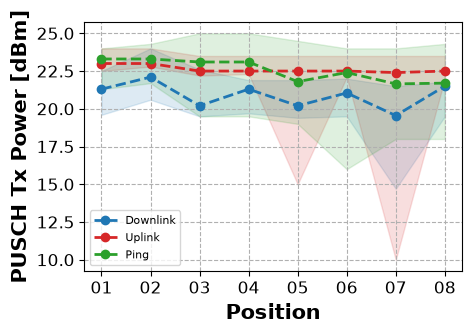

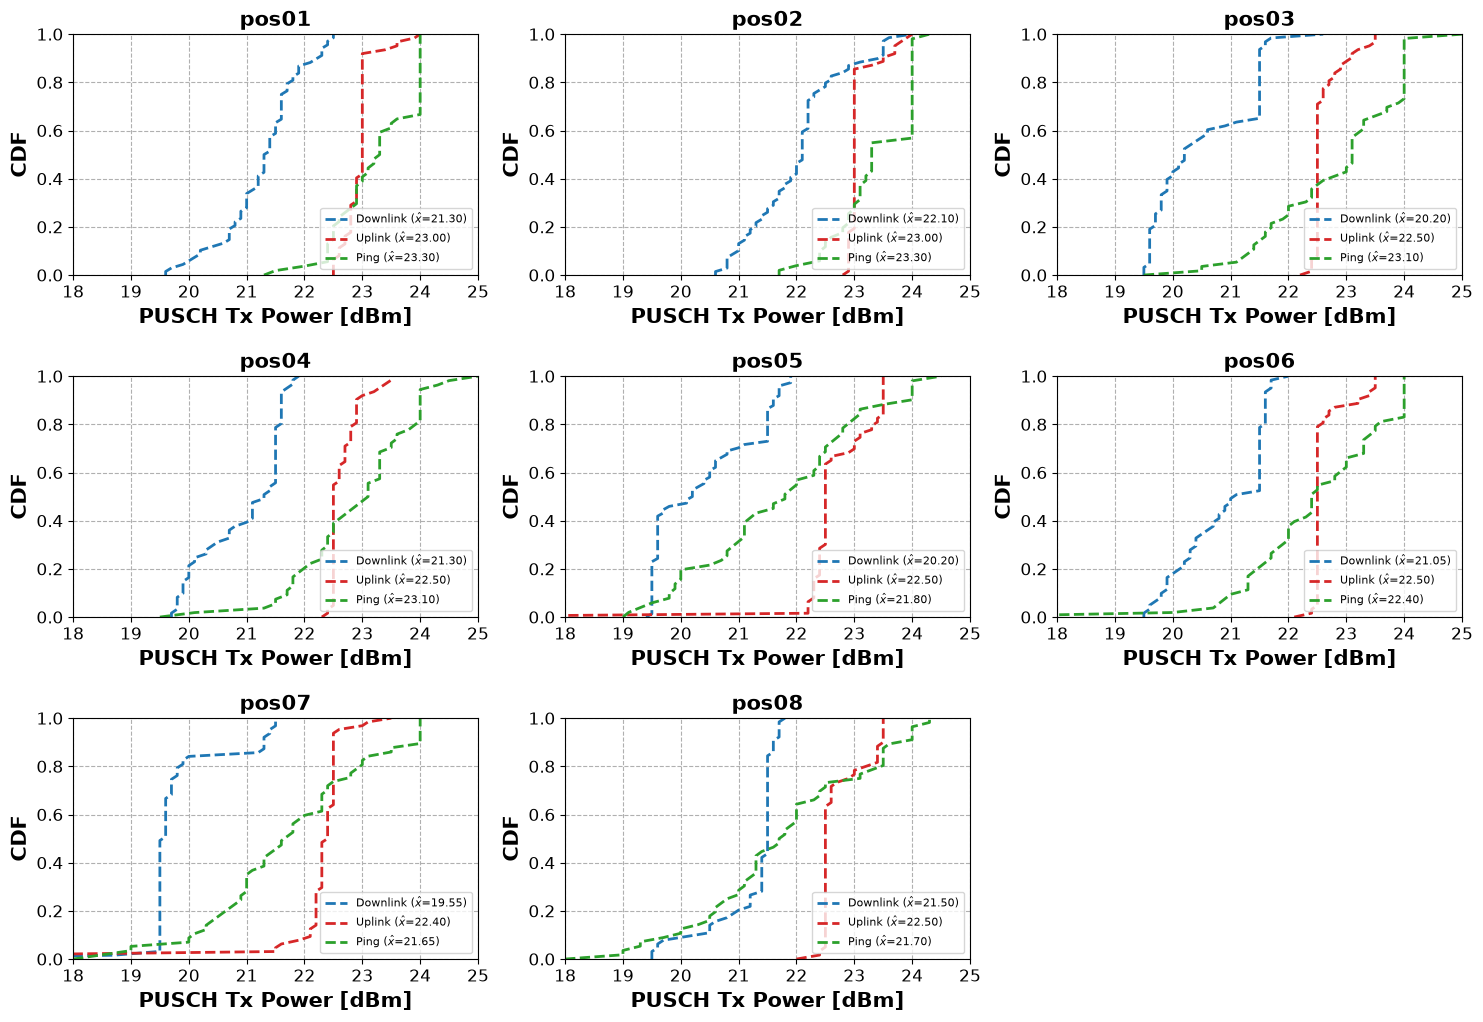

In [9]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends3pm_pos01',
    'pos02': '20260804_VzwLegends3pm_pos02',
    'pos03': '20260804_VzwLegends3pm_pos03',
    'pos04': '20260804_VzwLegends3pm_pos04',
    'pos05': '20260804_VzwLegends3pm_pos05',
    'pos06': '20260804_VzwLegends3pm_pos06',
    'pos07': '20260804_VzwLegends3pm_pos07',
    'pos08': '20260804_VzwLegends3pm_pos08_arfcnLock'
}

test_configurations = {
    'Downlink': {
        'Test Name': 'Capacity',
        'Direction': 'Downlink',
        'Status': 'Completed',
        'Color': 'tab:blue'
    },
    'Uplink': {
        'Test Name': 'Capacity',
        'Direction': 'Uplink',
        'Status': 'Completed',
        'Color': 'tab:red'
    },
    'Ping': {
        'Test Name': 'Ping',
        'Direction': 'Mixed',
        'Status': 'Completed',
        'Color': 'tab:green'
    }
}




positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))

fig, ax = plt.subplots(figsize=(5, 3.5))

for test_label, test_configuration in test_configurations.items():
    median_values = []
    minimum_values = []
    maximum_values = []

    for position, collection in position_collections.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'PUSCH Tx Power'].dropna()

        median_values.append(df_temp.median())
        minimum_values.append(df_temp.min())
        maximum_values.append(df_temp.max())

    median_values = np.array(median_values)
    minimum_values = np.array(minimum_values)
    maximum_values = np.array(maximum_values)

    ax.fill_between(
        x_positions, minimum_values, maximum_values,
        color=test_configuration['Color'], alpha=0.15
    )

    ax.plot(
        x_positions, median_values,
        label=test_label, marker='o', markersize=6,
        linewidth=2, linestyle="dashed",
        color=test_configuration['Color']
    )

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    for test_label, test_configuration in test_configurations.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'PUSCH Tx Power'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{test_label} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed",
            color=test_configuration['Color']
        )

    ax.set_title(position, fontsize=15, fontweight="bold")
    ax.set_xlabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(18, 25)
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

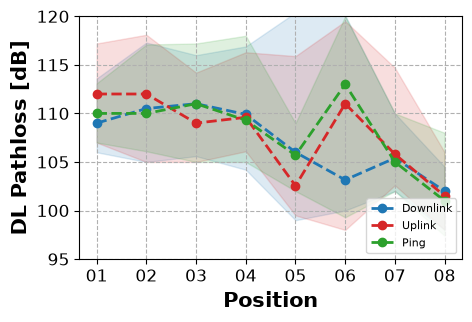

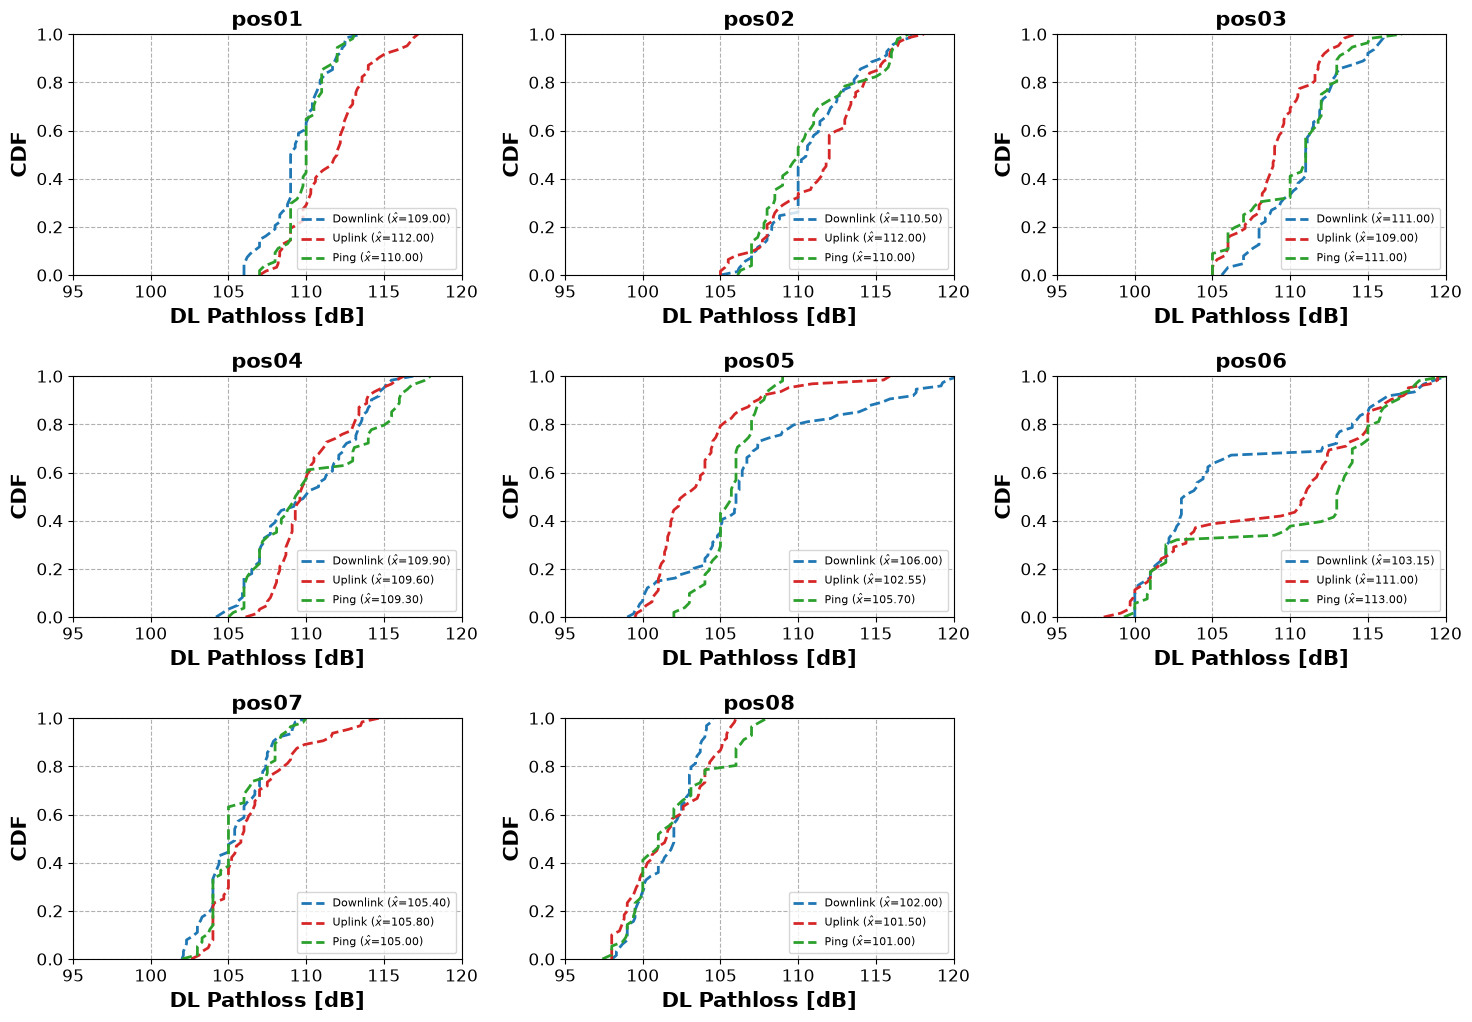

In [10]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends3pm_pos01',
    'pos02': '20260804_VzwLegends3pm_pos02',
    'pos03': '20260804_VzwLegends3pm_pos03',
    'pos04': '20260804_VzwLegends3pm_pos04',
    'pos05': '20260804_VzwLegends3pm_pos05',
    'pos06': '20260804_VzwLegends3pm_pos06',
    'pos07': '20260804_VzwLegends3pm_pos07',
    'pos08': '20260804_VzwLegends3pm_pos08_arfcnLock'
}

test_configurations = {
    'Downlink': {
        'Test Name': 'Capacity',
        'Direction': 'Downlink',
        'Color': 'tab:blue'
    },
    'Uplink': {
        'Test Name': 'Capacity',
        'Direction': 'Uplink',
        'Color': 'tab:red'
    },
    'Ping': {
        'Test Name': 'Ping',
        'Direction': 'Mixed',
        'Color': 'tab:green'
    }
}





positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))

fig, ax = plt.subplots(figsize=(5, 3.5))

for test_label, test_configuration in test_configurations.items():
    median_values = []
    minimum_values = []
    maximum_values = []

    for position, collection in position_collections.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna()

        median_values.append(df_temp.median())
        minimum_values.append(df_temp.min())
        maximum_values.append(df_temp.max())

    median_values = np.array(median_values)
    minimum_values = np.array(minimum_values)
    maximum_values = np.array(maximum_values)

    ax.fill_between(
        x_positions, minimum_values, maximum_values,
        color=test_configuration['Color'], alpha=0.15
    )

    ax.plot(
        x_positions, median_values,
        label=test_label, marker='o', markersize=6,
        linewidth=2, linestyle="dashed",
        color=test_configuration['Color']
    )

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.set_ylim(95, 120)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    for test_label, test_configuration in test_configurations.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{test_label} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed",
            color=test_configuration['Color']
        )

    ax.set_title(position, fontsize=15, fontweight="bold")
    ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(95, 120)
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

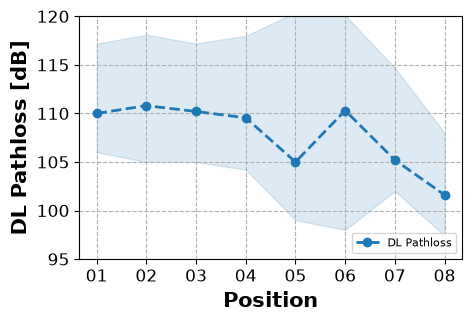

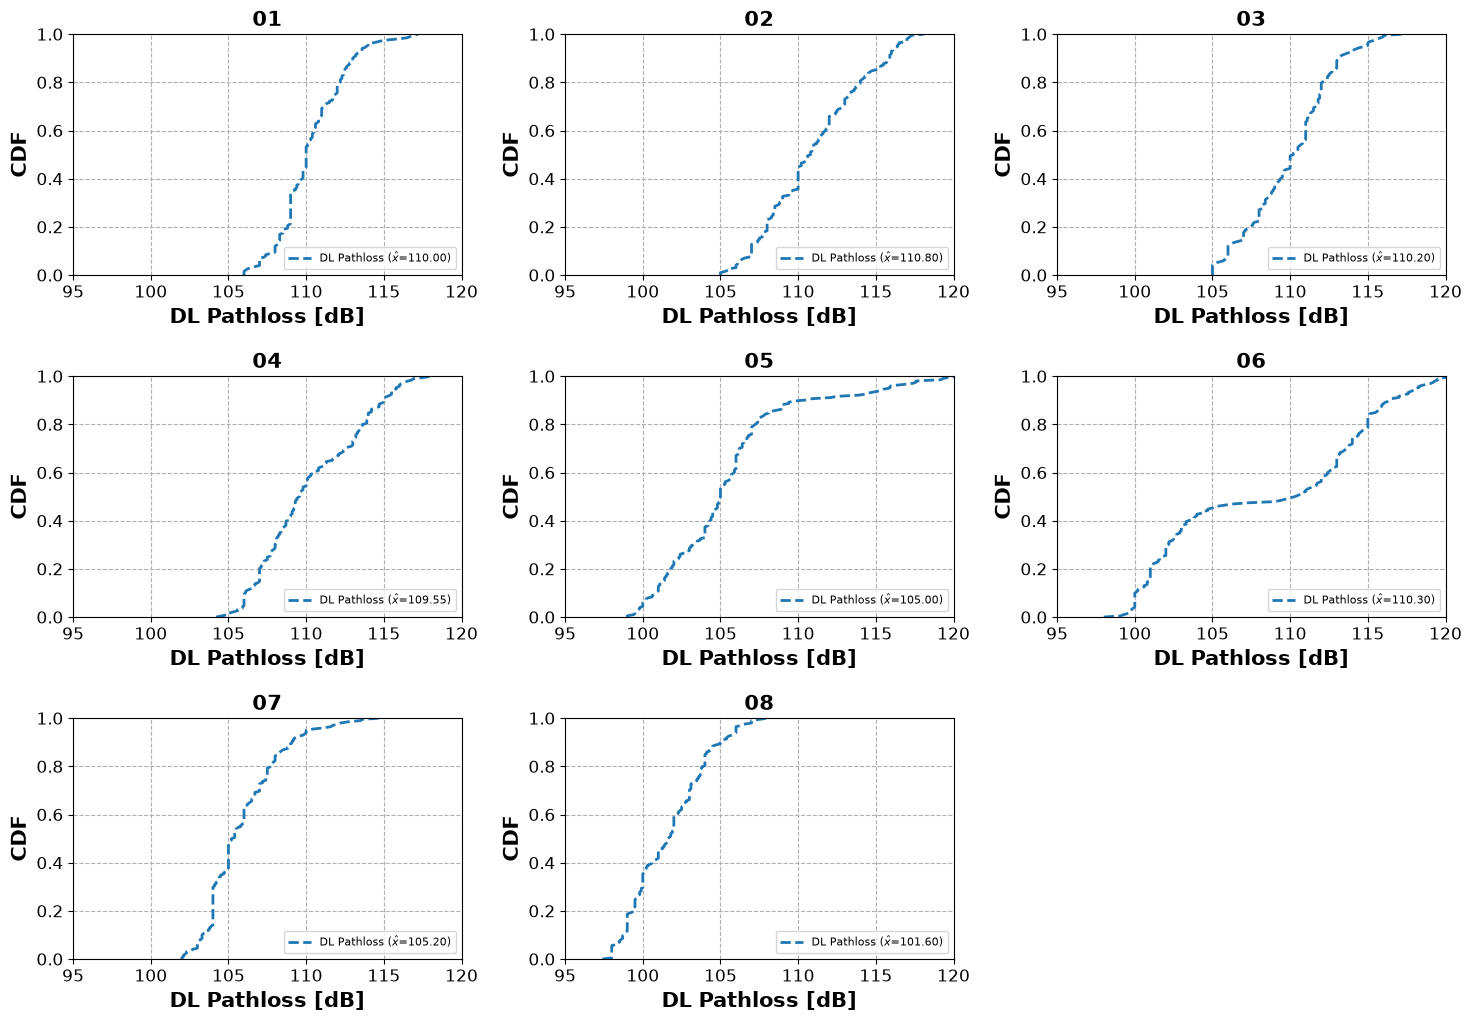

In [11]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends3pm_pos01',
    'pos02': '20260804_VzwLegends3pm_pos02',
    'pos03': '20260804_VzwLegends3pm_pos03',
    'pos04': '20260804_VzwLegends3pm_pos04',
    'pos05': '20260804_VzwLegends3pm_pos05',
    'pos06': '20260804_VzwLegends3pm_pos06',
    'pos07': '20260804_VzwLegends3pm_pos07',
    'pos08': '20260804_VzwLegends3pm_pos08_arfcnLock'
}





positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))

median_values = []
minimum_values = []
maximum_values = []

for position, collection in position_collections.items():
    mask = (
            nrPusch['Collection'] == collection
    )

    df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna()

    median_values.append(df_temp.median())
    minimum_values.append(df_temp.min())
    maximum_values.append(df_temp.max())

median_values = np.array(median_values)
minimum_values = np.array(minimum_values)
maximum_values = np.array(maximum_values)

fig, ax = plt.subplots(figsize=(5, 3.5))

ax.fill_between(
    x_positions, minimum_values, maximum_values,
    color="tab:blue", alpha=0.15
)

ax.plot(
    x_positions, median_values,
    label="DL Pathloss", marker='o', markersize=6,
    linewidth=2, linestyle="dashed", color="tab:blue"
)

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.set_ylim(95, 120)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    mask = (
            nrPusch['Collection'] == collection
    )

    df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna().sort_values()

    if df_temp.shape[0] > 0:
        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"DL Pathloss ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed", color="tab:blue"
        )

    ax.set_title(position.replace('pos', ''), fontsize=15, fontweight="bold")
    ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(95, 120)
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

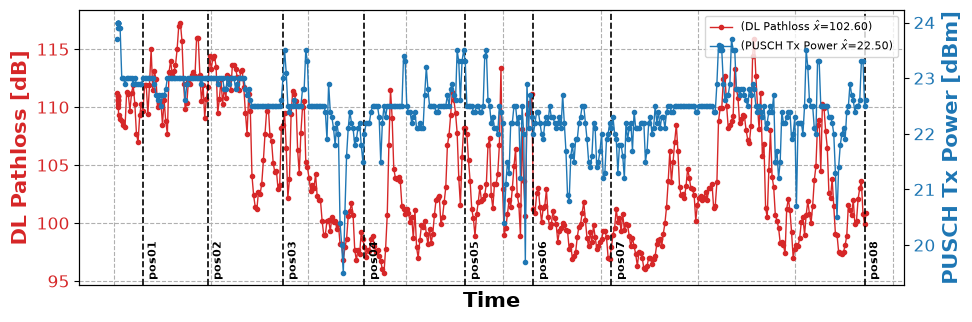

In [12]:
plt.rcParams["text.usetex"] = False

position_mask = (
        nrPusch['Collection'].str.match(
            r'^20260804_VzwLegends3pm_pos0[1-8](?:_arfcnLock)?$', na=False
        )
)

df_position = nrPusch.loc[position_mask, ['Collection', 'Latitude', 'Longitude']].dropna().copy()
df_position['Position'] = df_position['Collection'].str.extract(r'_pos(0[1-8])', expand=False)

position_average = df_position.groupby('Position')[['Latitude', 'Longitude']].mean().reset_index()

mask = (
        (nrPusch['Collection'] == '20260804_VzwLegends3pm_walkPos01-08_arfcnLock')
)

df_temp = nrPusch.loc[
    mask, ['Time', 'Latitude', 'Longitude', 'DL Pathloss', 'PUSCH Tx Power']
].dropna(subset=['Time', 'Latitude', 'Longitude']).sort_values('Time')

position_times = []

for _, position_row in position_average.iterrows():
    distance = (
        (df_temp['Latitude'] - position_row['Latitude']).abs()
        + (df_temp['Longitude'] - position_row['Longitude']).abs()
    )

    closest_index = distance.idxmin()

    position_times.append({
        'Position': 'pos' + position_row['Position'],
        'Time': df_temp.loc[closest_index, 'Time'],
        'DL Pathloss': df_temp.loc[closest_index, 'DL Pathloss'],
        'PUSCH Tx Power': df_temp.loc[closest_index, 'PUSCH Tx Power'],
        'Latitude': df_temp.loc[closest_index, 'Latitude'],
        'Longitude': df_temp.loc[closest_index, 'Longitude']
    })

position_times = pd.DataFrame(position_times)

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    df_temp['Time'], df_temp['DL Pathloss'],
    label=rf"(DL Pathloss $\hat{{x}}$={df_temp['DL Pathloss'].median():.2f})",
    marker='.', linewidth=1, linestyle="solid", color="tab:red"
)

ax2 = ax.twinx()
ax2.plot(
    df_temp['Time'], df_temp['PUSCH Tx Power'],
    label=rf"(PUSCH Tx Power $\hat{{x}}$={df_temp['PUSCH Tx Power'].median():.2f})",
    marker='.', linewidth=1, linestyle="solid", color="tab:blue"
)

for _, position_row in position_times.iterrows():
    ax.axvline(
        x=position_row['Time'],
        linewidth=1.2, linestyle="dashed", color="black", zorder=5
    )
    ax.annotate(
        position_row['Position'],
        xy=(position_row['Time'], 0.02),
        xytext=(3, 0), textcoords="offset points",
        xycoords=("data", "axes fraction"),
        ha="left", va="bottom", fontsize=8, fontweight="bold", rotation=90
    )

# ax.set_title("Point A", fontsize=15, fontweight="bold")
ax.set_xlabel("Time", fontsize=15, fontweight="bold")
ax.set_ylabel("DL Pathloss [dB]", fontsize=15, fontweight="bold", color="tab:red")
ax2.set_ylabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold", color="tab:blue")
ax.yaxis.set_minor_locator(AutoLocator())
ax2.yaxis.set_minor_locator(AutoLocator())
# plt.xlim(22, 24)
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="y", labelsize=12, labelcolor="tab:red")
ax2.tick_params(axis="y", labelsize=12, labelcolor="tab:blue")
plt.xticks(fontsize=12)

ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False) # hide x-axis values

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

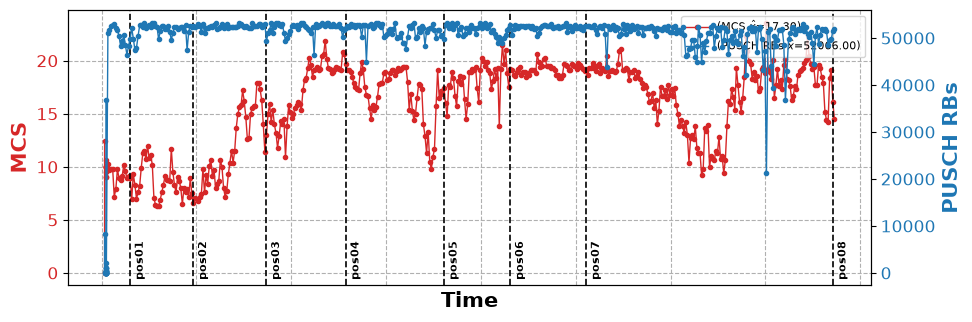

In [31]:
plt.rcParams["text.usetex"] = False

position_mask = (
        nrPusch['Collection'].str.match(
            r'^20260804_VzwLegends3pm_pos0[1-8](?:_arfcnLock)?$', na=False
        )
)

df_position = nrPusch.loc[position_mask, ['Collection', 'Latitude', 'Longitude']].dropna().copy()
df_position['Position'] = df_position['Collection'].str.extract(r'_pos(0[1-8])', expand=False)

position_average = df_position.groupby('Position')[['Latitude', 'Longitude']].mean().reset_index()

mask = (
        (nrPusch['Collection'] == '20260804_VzwLegends3pm_walkPos01-08_arfcnLock')
)

df_temp = nrPusch.loc[
    mask, ['Time', 'Latitude', 'Longitude', 'MCS', 'PUSCH RBs']
].dropna(subset=['Time', 'Latitude', 'Longitude']).sort_values('Time')

position_times = []

for _, position_row in position_average.iterrows():
    distance = (
        (df_temp['Latitude'] - position_row['Latitude']).abs()
        + (df_temp['Longitude'] - position_row['Longitude']).abs()
    )

    closest_index = distance.idxmin()

    position_times.append({
        'Position': 'pos' + position_row['Position'],
        'Time': df_temp.loc[closest_index, 'Time'],
        'MCS': df_temp.loc[closest_index, 'MCS'],
        'PUSCH RBs': df_temp.loc[closest_index, 'PUSCH RBs'],
        'Latitude': df_temp.loc[closest_index, 'Latitude'],
        'Longitude': df_temp.loc[closest_index, 'Longitude']
    })

position_times = pd.DataFrame(position_times)

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    df_temp['Time'], df_temp['MCS'],
    label=rf"(MCS $\hat{{x}}$={df_temp['MCS'].median():.2f})",
    marker='.', linewidth=1, linestyle="solid", color="tab:red"
)

ax2 = ax.twinx()
ax2.plot(
    df_temp['Time'], df_temp['PUSCH RBs'],
    label=rf"(PUSCH RBs $\hat{{x}}$={df_temp['PUSCH RBs'].median():.2f})",
    marker='.', linewidth=1, linestyle="solid", color="tab:blue"
)

for _, position_row in position_times.iterrows():
    ax.axvline(
        x=position_row['Time'],
        linewidth=1.2, linestyle="dashed", color="black", zorder=5
    )
    ax.annotate(
        position_row['Position'],
        xy=(position_row['Time'], 0.02),
        xytext=(3, 0), textcoords="offset points",
        xycoords=("data", "axes fraction"),
        ha="left", va="bottom", fontsize=8, fontweight="bold", rotation=90
    )

# ax.set_title("Point A", fontsize=15, fontweight="bold")
ax.set_xlabel("Time", fontsize=15, fontweight="bold")
ax.set_ylabel("MCS", fontsize=15, fontweight="bold", color="tab:red")
ax2.set_ylabel("PUSCH RBs", fontsize=15, fontweight="bold", color="tab:blue")
ax.yaxis.set_minor_locator(AutoLocator())
ax2.yaxis.set_minor_locator(AutoLocator())
# plt.xlim(22, 24)
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="y", labelsize=12, labelcolor="tab:red")
ax2.tick_params(axis="y", labelsize=12, labelcolor="tab:blue")
plt.xticks(fontsize=12)

ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False) # hide x-axis values

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

### 20260804-9-30pm VZW

In [13]:
mask = (nrRadio['Collection'].isin([
                '20260804_VzwLegends9-30pm_arfcnLock_pos01', '20260804_VzwLegends9-30pm_arfcnLock_pos02', 
                '20260804_VzwLegends9-30pm_arfcnLock_pos03', '20260804_VzwLegends9-30pm_arfcnLock_pos04',
                '20260804_VzwLegends9-30pm_arfcnLock_pos05', '20260804_VzwLegends9-30pm_arfcnLock_pos06',
                '20260804_VzwLegends9-30pm_arfcnLock_pos07',
                            ]))
plot_geo_scatter_map(nrRadio[mask], value_col='SS-RSRP', title="", colorbar_title="SS-RSRP")

In [14]:
mask = (nrRadio['Collection'] == '20260804_VzwLegends9-30pm_arfcnLock_walkPos01-07')
plot_geo_scatter_map(nrRadio[mask], value_col='SS-RSRP', title="", colorbar_title="SS-RSRP", dir_arrow=True)

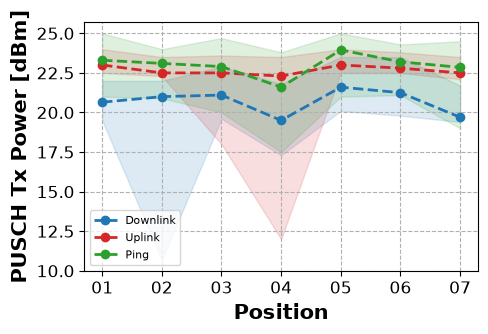

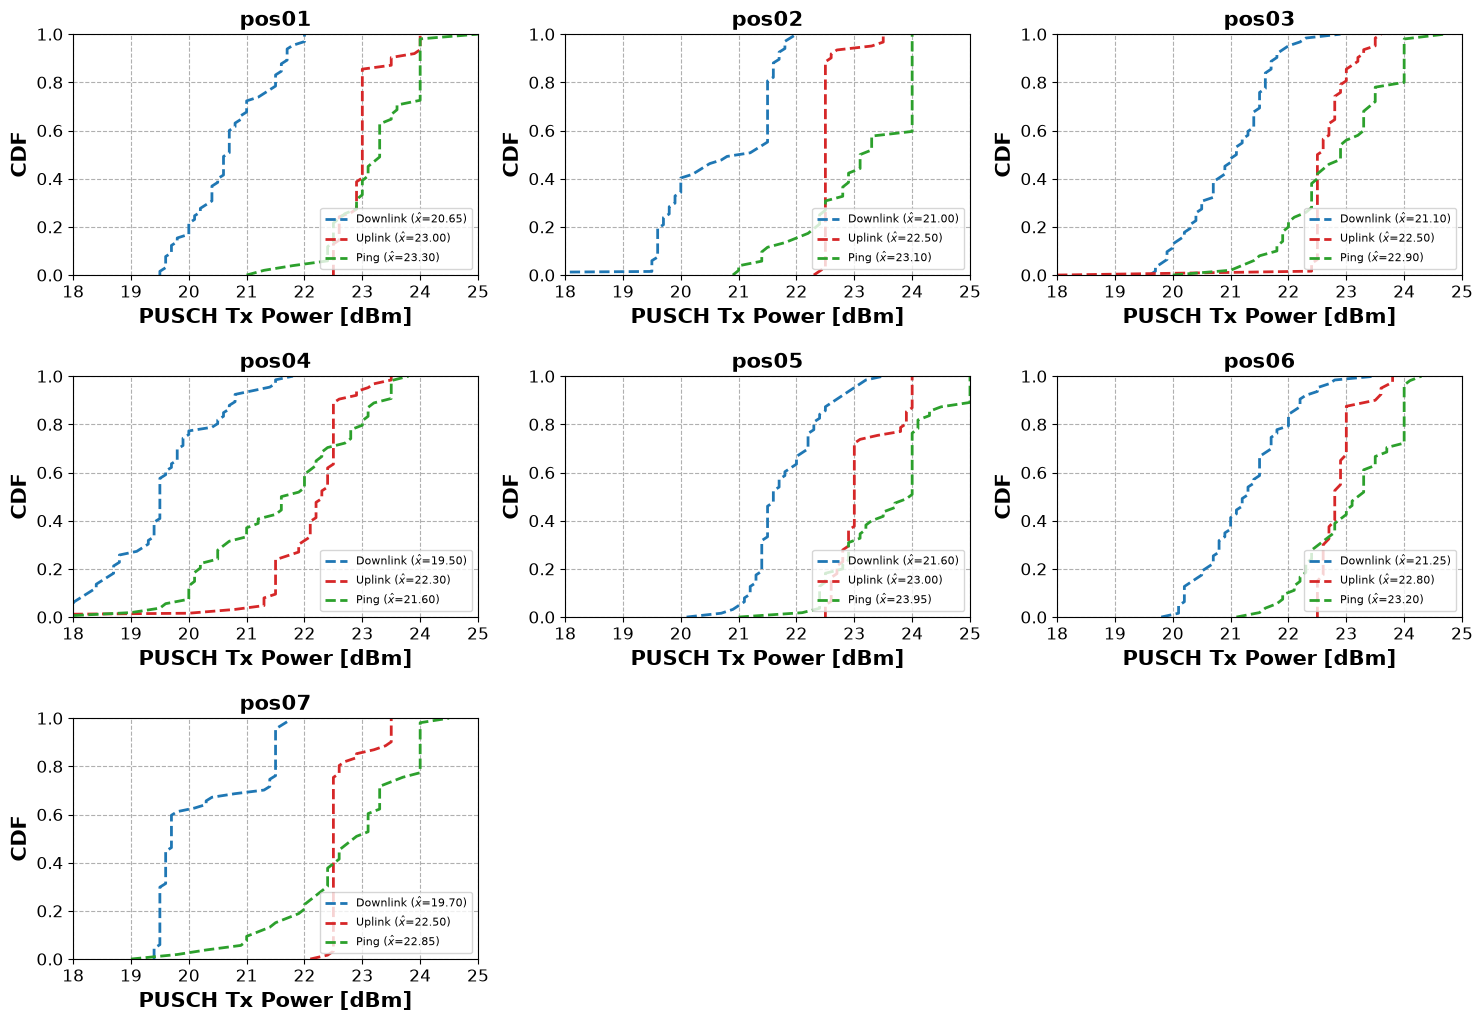

In [15]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9-30pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9-30pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9-30pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9-30pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9-30pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9-30pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9-30pm_arfcnLock_pos07',
}

test_configurations = {
    'Downlink': {
        'Test Name': 'Capacity',
        'Direction': 'Downlink',
        'Status': 'Completed',
        'Color': 'tab:blue'
    },
    'Uplink': {
        'Test Name': 'Capacity',
        'Direction': 'Uplink',
        'Status': 'Completed',
        'Color': 'tab:red'
    },
    'Ping': {
        'Test Name': 'Ping',
        'Direction': 'Mixed',
        'Status': 'Completed',
        'Color': 'tab:green'
    }
}




positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))

fig, ax = plt.subplots(figsize=(5, 3.5))

for test_label, test_configuration in test_configurations.items():
    median_values = []
    minimum_values = []
    maximum_values = []

    for position, collection in position_collections.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'PUSCH Tx Power'].dropna()

        median_values.append(df_temp.median())
        minimum_values.append(df_temp.min())
        maximum_values.append(df_temp.max())

    median_values = np.array(median_values)
    minimum_values = np.array(minimum_values)
    maximum_values = np.array(maximum_values)

    ax.fill_between(
        x_positions, minimum_values, maximum_values,
        color=test_configuration['Color'], alpha=0.15
    )

    ax.plot(
        x_positions, median_values,
        label=test_label, marker='o', markersize=6,
        linewidth=2, linestyle="dashed",
        color=test_configuration['Color']
    )

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    for test_label, test_configuration in test_configurations.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'PUSCH Tx Power'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{test_label} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed",
            color=test_configuration['Color']
        )

    ax.set_title(position, fontsize=15, fontweight="bold")
    ax.set_xlabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(18, 25)
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.tight_layout()
plt.show()

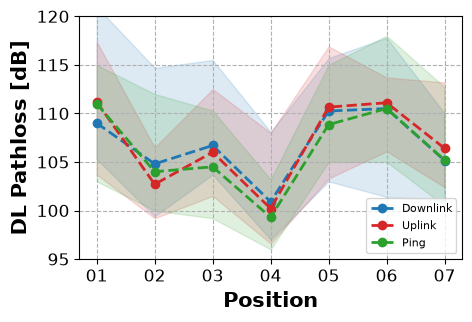

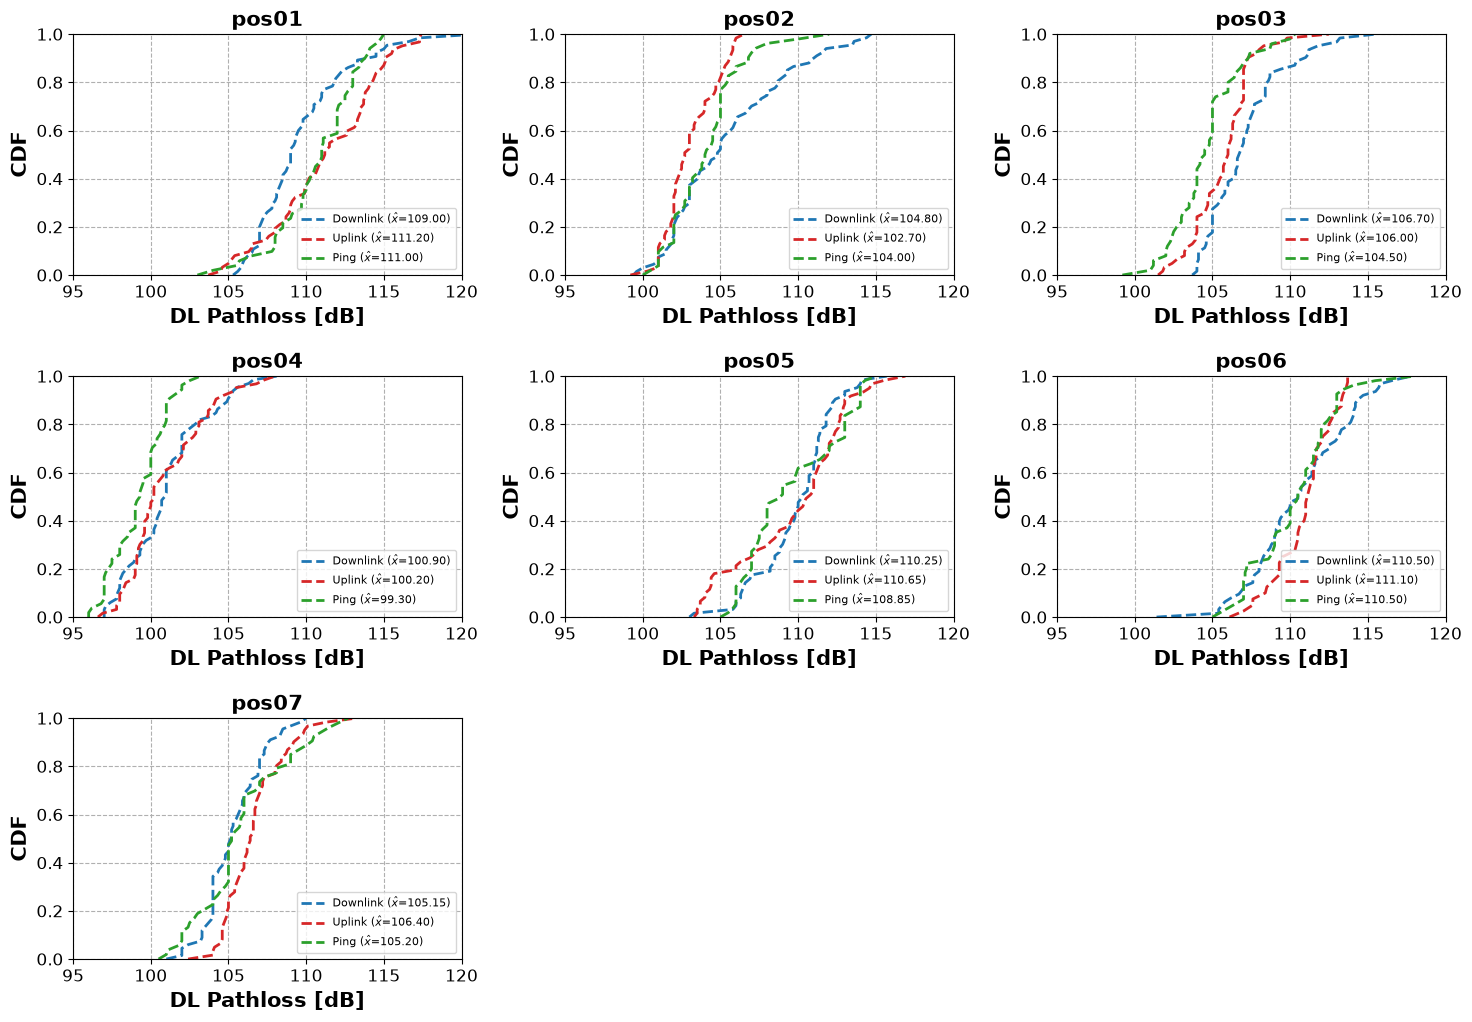

In [16]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9-30pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9-30pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9-30pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9-30pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9-30pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9-30pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9-30pm_arfcnLock_pos07',
}

test_configurations = {
    'Downlink': {
        'Test Name': 'Capacity',
        'Direction': 'Downlink',
        'Color': 'tab:blue'
    },
    'Uplink': {
        'Test Name': 'Capacity',
        'Direction': 'Uplink',
        'Color': 'tab:red'
    },
    'Ping': {
        'Test Name': 'Ping',
        'Direction': 'Mixed',
        'Color': 'tab:green'
    }
}





positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))

fig, ax = plt.subplots(figsize=(5, 3.5))

for test_label, test_configuration in test_configurations.items():
    median_values = []
    minimum_values = []
    maximum_values = []

    for position, collection in position_collections.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna()

        median_values.append(df_temp.median())
        minimum_values.append(df_temp.min())
        maximum_values.append(df_temp.max())

    median_values = np.array(median_values)
    minimum_values = np.array(minimum_values)
    maximum_values = np.array(maximum_values)

    ax.fill_between(
        x_positions, minimum_values, maximum_values,
        color=test_configuration['Color'], alpha=0.15
    )

    ax.plot(
        x_positions, median_values,
        label=test_label, marker='o', markersize=6,
        linewidth=2, linestyle="dashed",
        color=test_configuration['Color']
    )

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.set_ylim(95, 120)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    for test_label, test_configuration in test_configurations.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{test_label} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed",
            color=test_configuration['Color']
        )

    ax.set_title(position, fontsize=15, fontweight="bold")
    ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(95, 120)
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.tight_layout()
plt.show()

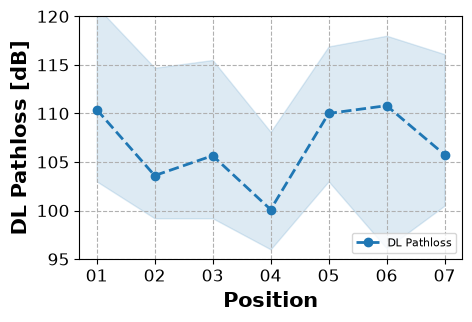

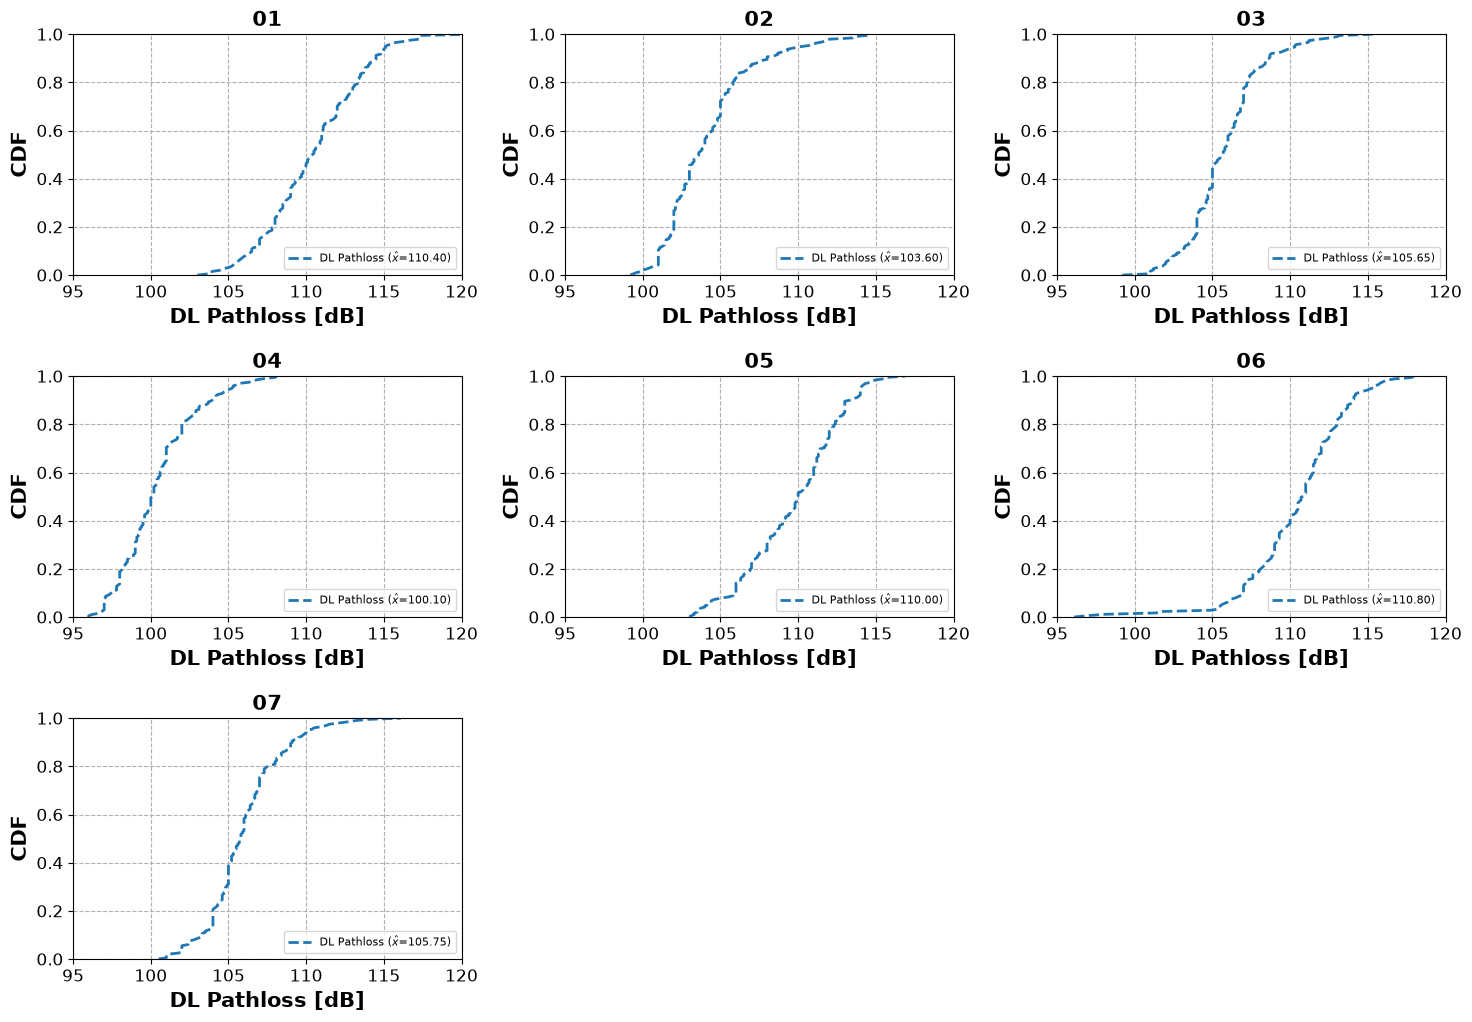

In [17]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9-30pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9-30pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9-30pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9-30pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9-30pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9-30pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9-30pm_arfcnLock_pos07',
}





positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))

median_values = []
minimum_values = []
maximum_values = []

for position, collection in position_collections.items():
    mask = (
            nrPusch['Collection'] == collection
    )

    df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna()

    median_values.append(df_temp.median())
    minimum_values.append(df_temp.min())
    maximum_values.append(df_temp.max())

median_values = np.array(median_values)
minimum_values = np.array(minimum_values)
maximum_values = np.array(maximum_values)

fig, ax = plt.subplots(figsize=(5, 3.5))

ax.fill_between(
    x_positions, minimum_values, maximum_values,
    color="tab:blue", alpha=0.15
)

ax.plot(
    x_positions, median_values,
    label="DL Pathloss", marker='o', markersize=6,
    linewidth=2, linestyle="dashed", color="tab:blue"
)

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.set_ylim(95, 120)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    mask = (
            nrPusch['Collection'] == collection
    )

    df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna().sort_values()

    if df_temp.shape[0] > 0:
        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"DL Pathloss ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed", color="tab:blue"
        )

    ax.set_title(position.replace('pos', ''), fontsize=15, fontweight="bold")
    ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(95, 120)
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.tight_layout()
plt.show()

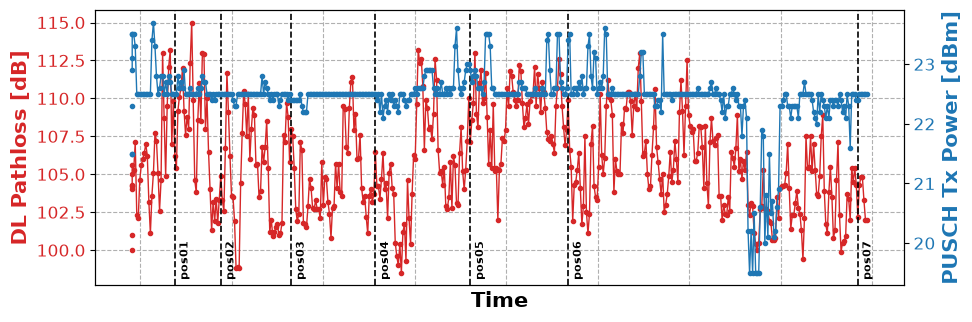

In [18]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9-30pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9-30pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9-30pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9-30pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9-30pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9-30pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9-30pm_arfcnLock_pos07',
}

position_mask = (
        nrPusch['Collection'].isin(position_collections.values())
)

df_position = nrPusch.loc[position_mask, ['Collection', 'Latitude', 'Longitude']].dropna().copy()

collection_to_position = {
    collection: position for position, collection in position_collections.items()
}

df_position['Position'] = df_position['Collection'].map(collection_to_position)

position_average = df_position.groupby('Position')[['Latitude', 'Longitude']].mean().reset_index()

mask = (
        nrPusch['Collection'] == '20260804_VzwLegends9-30pm_arfcnLock_walkPos01-07'
)

df_temp = nrPusch.loc[
    mask, ['Time', 'Latitude', 'Longitude', 'DL Pathloss', 'PUSCH Tx Power']
].dropna(subset=['Time', 'Latitude', 'Longitude']).sort_values('Time')

position_times = []

for _, position_row in position_average.iterrows():
    distance = (
        (df_temp['Latitude'] - position_row['Latitude']).abs()
        + (df_temp['Longitude'] - position_row['Longitude']).abs()
    )

    closest_index = distance.idxmin()

    position_times.append({
        'Position': position_row['Position'],
        'Time': df_temp.loc[closest_index, 'Time'],
        'DL Pathloss': df_temp.loc[closest_index, 'DL Pathloss'],
        'PUSCH Tx Power': df_temp.loc[closest_index, 'PUSCH Tx Power'],
        'Latitude': df_temp.loc[closest_index, 'Latitude'],
        'Longitude': df_temp.loc[closest_index, 'Longitude']
    })

position_times = pd.DataFrame(position_times)

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    df_temp['Time'], df_temp['DL Pathloss'],
    label=rf"(DL Pathloss $\hat{{x}}$={df_temp['DL Pathloss'].median():.2f})",
    marker='.', linewidth=1, linestyle="solid", color="tab:red"
)

ax2 = ax.twinx()
ax2.plot(
    df_temp['Time'], df_temp['PUSCH Tx Power'],
    label=rf"(PUSCH Tx Power $\hat{{x}}$={df_temp['PUSCH Tx Power'].median():.2f})",
    marker='.', linewidth=1, linestyle="solid", color="tab:blue"
)

for _, position_row in position_times.iterrows():
    ax.axvline(
        x=position_row['Time'],
        linewidth=1.2, linestyle="dashed", color="black", zorder=5
    )
    ax.annotate(
        position_row['Position'],
        xy=(position_row['Time'], 0.02),
        xytext=(3, 0), textcoords="offset points",
        xycoords=("data", "axes fraction"),
        ha="left", va="bottom", fontsize=8, fontweight="bold", rotation=90
    )

# ax.set_title("Point A", fontsize=15, fontweight="bold")
ax.set_xlabel("Time", fontsize=15, fontweight="bold")
ax.set_ylabel("DL Pathloss [dB]", fontsize=15, fontweight="bold", color="tab:red")
ax2.set_ylabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold", color="tab:blue")
ax.yaxis.set_minor_locator(AutoLocator())
ax2.yaxis.set_minor_locator(AutoLocator())
# plt.xlim(22, 24)
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="y", labelsize=12, labelcolor="tab:red")
ax2.tick_params(axis="y", labelsize=12, labelcolor="tab:blue")
plt.xticks(fontsize=12)

ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False) # hide x-axis values

# lines1, labels1 = ax.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

### 20260804-9pm VZW

In [19]:
mask = (nrRadio['Collection'].isin([
                '20260804_VzwLegends9pm_arfcnLock_pos01', '20260804_VzwLegends9pm_arfcnLock_pos02', 
                '20260804_VzwLegends9pm_arfcnLock_pos03', '20260804_VzwLegends9pm_arfcnLock_pos04',
                '20260804_VzwLegends9pm_arfcnLock_pos05', '20260804_VzwLegends9pm_arfcnLock_pos06',
                '20260804_VzwLegends9pm_arfcnLock_pos07', '20260804_VzwLegends9pm_arfcnLock_pos08',
                '20260804_VzwLegends9pm_arfcnLock_pos09',
                            ]))
plot_geo_scatter_map(nrRadio[mask], value_col='SS-RSRP', title="", colorbar_title="SS-RSRP")

In [20]:
mask = (nrRadio['Collection'] == '20260804_VzwLegends9pm_arfcnLock_walkPos01-09')
plot_geo_scatter_map(nrRadio[mask], value_col='SS-RSRP', title="", colorbar_title="SS-RSRP", dir_arrow=True)

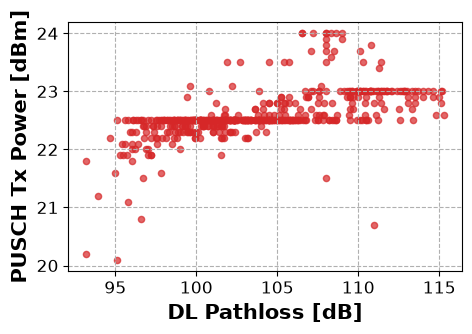

In [61]:
plt.rcParams["text.usetex"] = False

mask = (
        (nrPusch['Collection'] == '20260804_VzwLegends9pm_arfcnLock_walkPos01-09')
)

df_temp = nrPusch.loc[mask, ['DL Pathloss', 'PUSCH Tx Power']].dropna()

fig, ax = plt.subplots(figsize=(5, 3.5))

ax.scatter(
    df_temp['DL Pathloss'], df_temp['PUSCH Tx Power'],
    s=20, color="tab:red", alpha=0.7
)

ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_ylabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
ax.xaxis.set_minor_locator(AutoLocator())
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

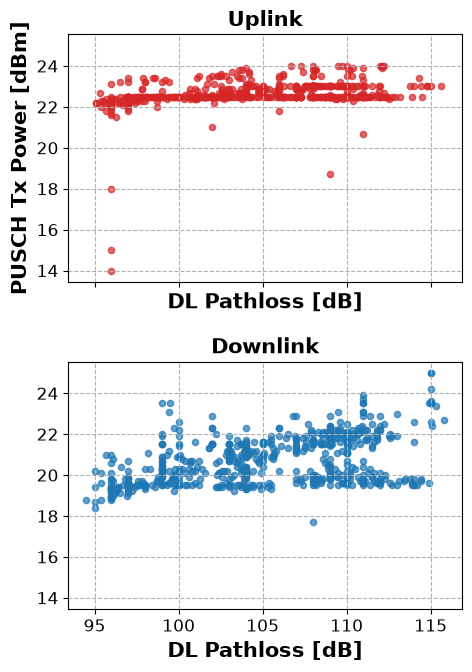

In [60]:
plt.rcParams["text.usetex"] = False

position_mask = nrPusch['Collection'].str.match(
    r'^20260804_VzwLegends9pm_arfcnLock_pos0[1-9]$', na=False
)

fig, axes = plt.subplots(2, 1, figsize=(5, 7), sharex=True, sharey=True)

for ax, direction, color in zip(axes, ['Uplink', 'Downlink'], ['tab:red', 'tab:blue']):
    mask = (
            position_mask &
            (nrPusch['Test Name'] == 'Capacity') &
            (nrPusch['Direction'] == direction) &
            (nrPusch['Test Status'] == 'Completed')
    )

    df_temp = nrPusch.loc[mask, ['DL Pathloss', 'PUSCH Tx Power']].dropna()

    ax.scatter(
        df_temp['DL Pathloss'], df_temp['PUSCH Tx Power'],
        s=20, color=color, alpha=0.7
    )

    ax.set_title(direction, fontsize=15, fontweight="bold")
    ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
    ax.xaxis.set_minor_locator(AutoLocator())
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)

axes[0].set_ylabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

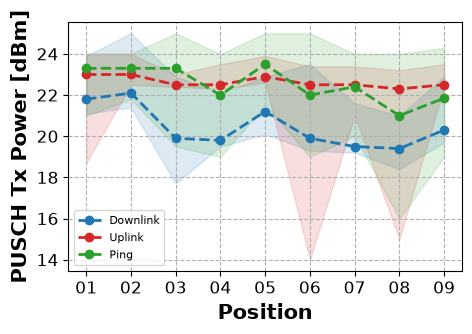

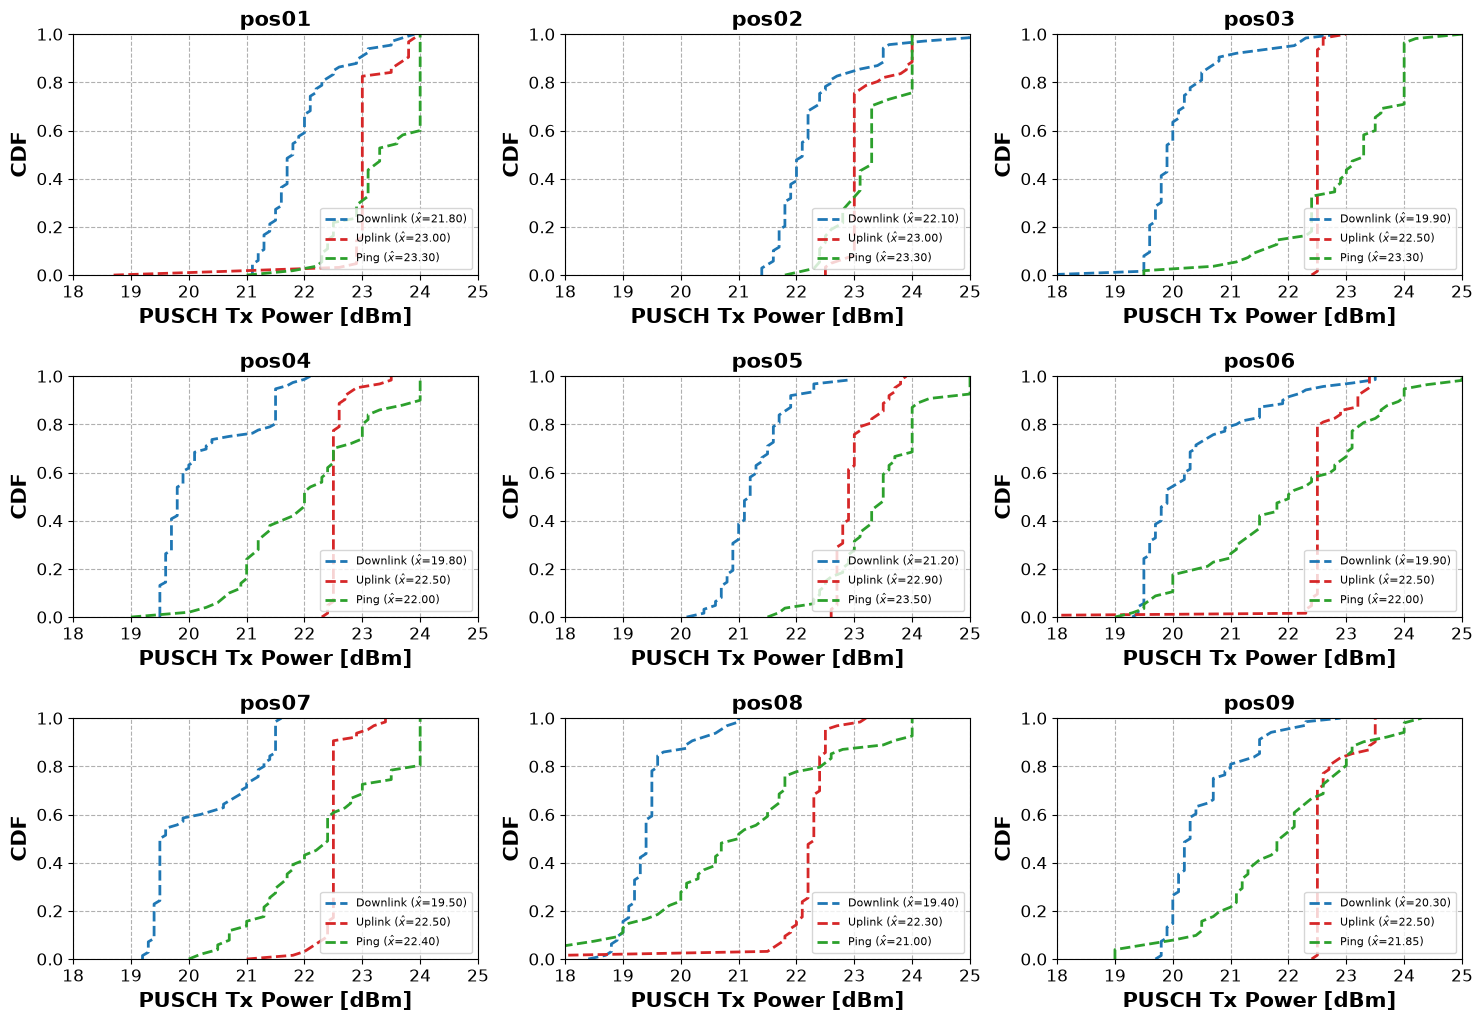

In [21]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9pm_arfcnLock_pos07',
    'pos08': '20260804_VzwLegends9pm_arfcnLock_pos08',
    'pos09': '20260804_VzwLegends9pm_arfcnLock_pos09'
}

test_configurations = {
    'Downlink': {
        'Test Name': 'Capacity',
        'Direction': 'Downlink',
        'Status': 'Completed',
        'Color': 'tab:blue'
    },
    'Uplink': {
        'Test Name': 'Capacity',
        'Direction': 'Uplink',
        'Status': 'Completed',
        'Color': 'tab:red'
    },
    'Ping': {
        'Test Name': 'Ping',
        'Direction': 'Mixed',
        'Status': 'Completed',
        'Color': 'tab:green'
    }
}




positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))

fig, ax = plt.subplots(figsize=(5, 3.5))

for test_label, test_configuration in test_configurations.items():
    median_values = []
    minimum_values = []
    maximum_values = []

    for position, collection in position_collections.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'PUSCH Tx Power'].dropna()

        median_values.append(df_temp.median())
        minimum_values.append(df_temp.min())
        maximum_values.append(df_temp.max())

    median_values = np.array(median_values)
    minimum_values = np.array(minimum_values)
    maximum_values = np.array(maximum_values)

    ax.fill_between(
        x_positions, minimum_values, maximum_values,
        color=test_configuration['Color'], alpha=0.15
    )

    ax.plot(
        x_positions, median_values,
        label=test_label, marker='o', markersize=6,
        linewidth=2, linestyle="dashed",
        color=test_configuration['Color']
    )

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    for test_label, test_configuration in test_configurations.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'PUSCH Tx Power'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{test_label} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed",
            color=test_configuration['Color']
        )

    ax.set_title(position, fontsize=15, fontweight="bold")
    ax.set_xlabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(18, 25)
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

# axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

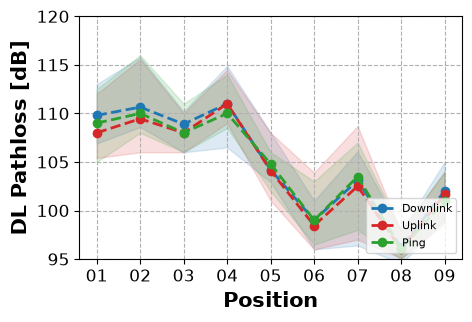

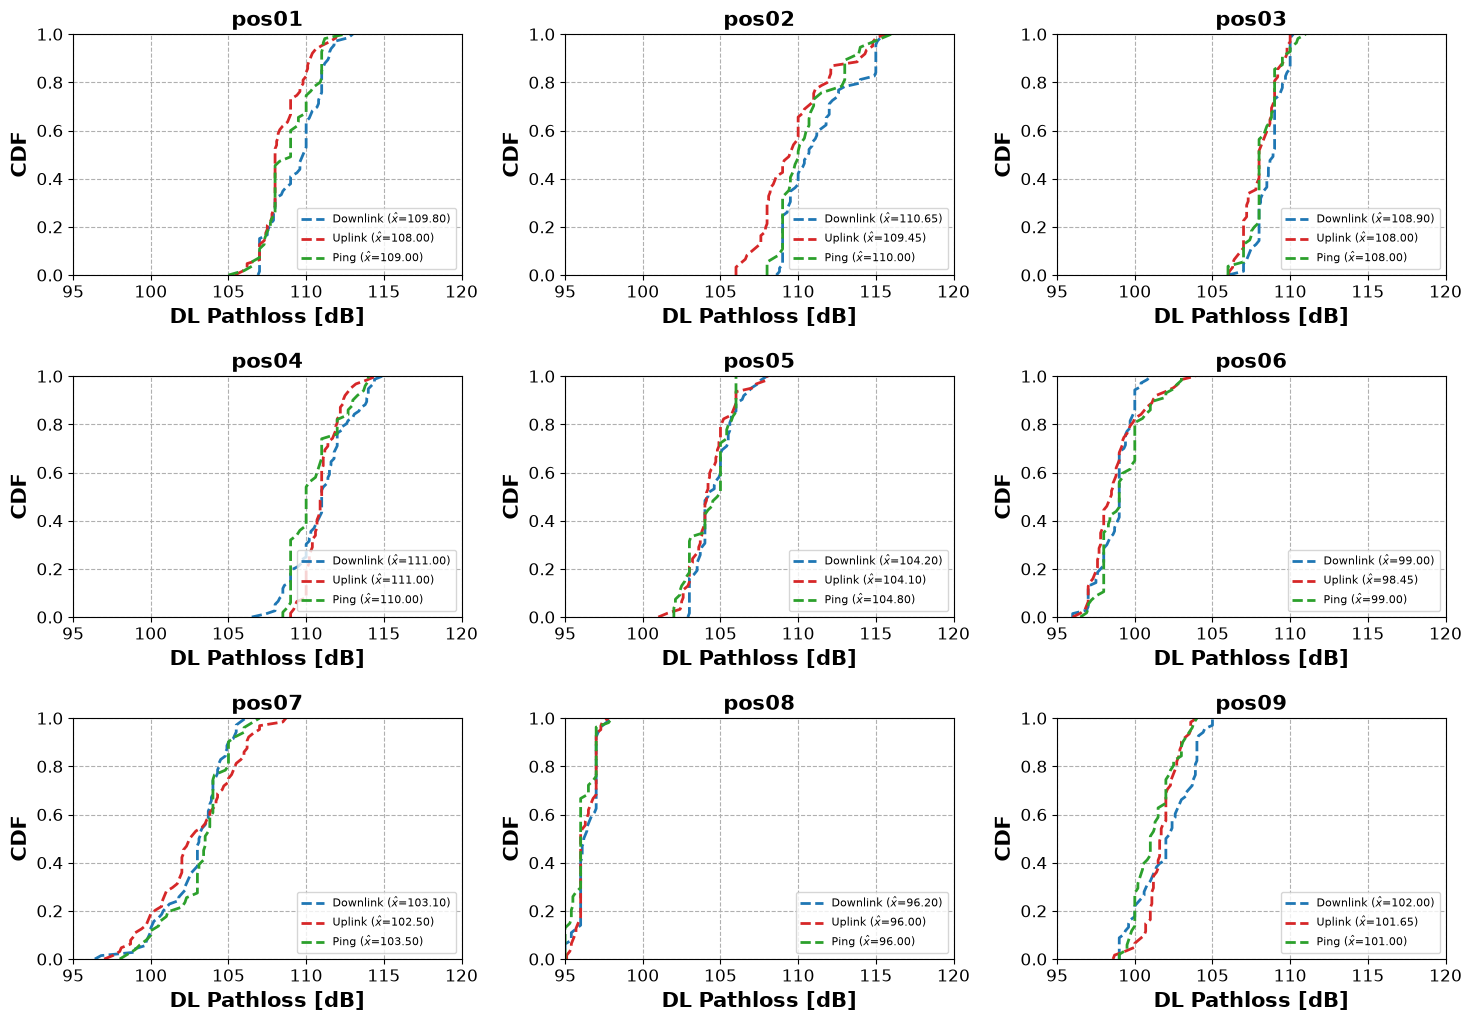

In [22]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9pm_arfcnLock_pos07',
    'pos08': '20260804_VzwLegends9pm_arfcnLock_pos08',
    'pos09': '20260804_VzwLegends9pm_arfcnLock_pos09'
}

test_configurations = {
    'Downlink': {
        'Test Name': 'Capacity',
        'Direction': 'Downlink',
        'Color': 'tab:blue'
    },
    'Uplink': {
        'Test Name': 'Capacity',
        'Direction': 'Uplink',
        'Color': 'tab:red'
    },
    'Ping': {
        'Test Name': 'Ping',
        'Direction': 'Mixed',
        'Color': 'tab:green'
    }
}





positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))

fig, ax = plt.subplots(figsize=(5, 3.5))

for test_label, test_configuration in test_configurations.items():
    median_values = []
    minimum_values = []
    maximum_values = []

    for position, collection in position_collections.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna()

        median_values.append(df_temp.median())
        minimum_values.append(df_temp.min())
        maximum_values.append(df_temp.max())

    median_values = np.array(median_values)
    minimum_values = np.array(minimum_values)
    maximum_values = np.array(maximum_values)

    ax.fill_between(
        x_positions, minimum_values, maximum_values,
        color=test_configuration['Color'], alpha=0.15
    )

    ax.plot(
        x_positions, median_values,
        label=test_label, marker='o', markersize=6,
        linewidth=2, linestyle="dashed",
        color=test_configuration['Color']
    )

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.set_ylim(95, 120)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    for test_label, test_configuration in test_configurations.items():
        mask = (
                (nrPusch['Collection'] == collection) &
                (nrPusch['Test Name'] == test_configuration['Test Name']) &
                (nrPusch['Direction'] == test_configuration['Direction']) &
                (nrPusch['Test Status'] == 'Completed')
        )

        df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{test_label} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed",
            color=test_configuration['Color']
        )

    ax.set_title(position, fontsize=15, fontweight="bold")
    ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(95, 120)
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

# axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

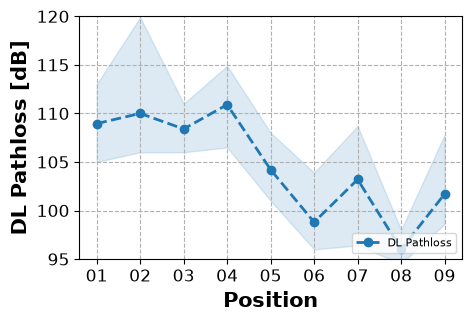

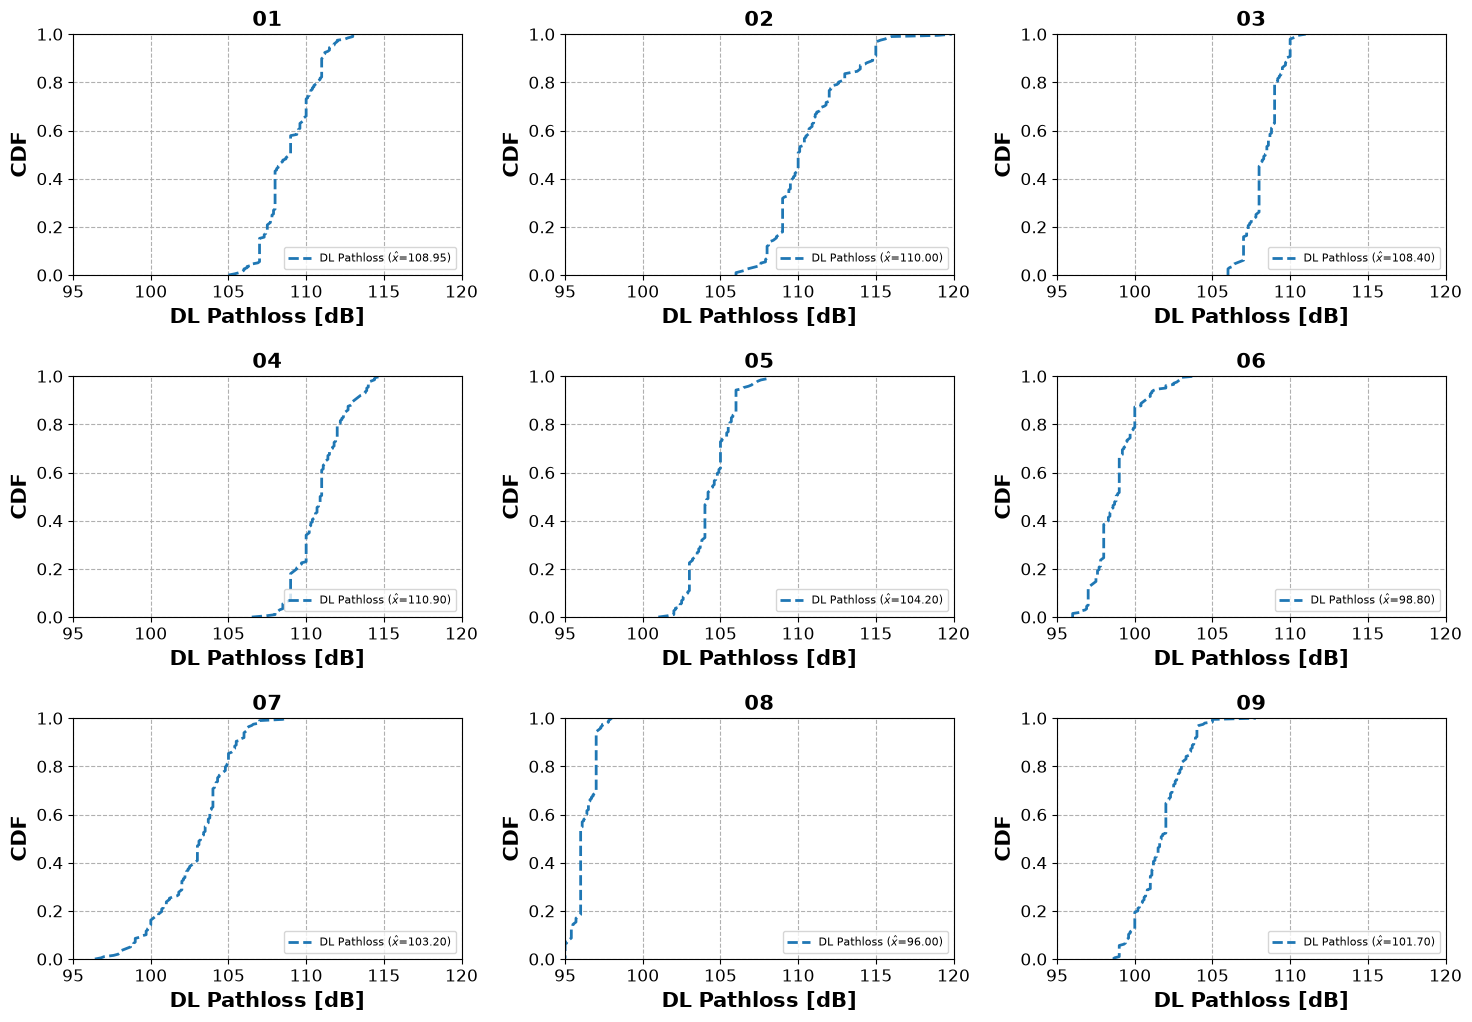

In [23]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9pm_arfcnLock_pos07',
    'pos08': '20260804_VzwLegends9pm_arfcnLock_pos08',
    'pos09': '20260804_VzwLegends9pm_arfcnLock_pos09'
}





positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))

median_values = []
minimum_values = []
maximum_values = []

for position, collection in position_collections.items():
    mask = (
            nrPusch['Collection'] == collection
    )

    df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna()

    median_values.append(df_temp.median())
    minimum_values.append(df_temp.min())
    maximum_values.append(df_temp.max())

median_values = np.array(median_values)
minimum_values = np.array(minimum_values)
maximum_values = np.array(maximum_values)

fig, ax = plt.subplots(figsize=(5, 3.5))

ax.fill_between(
    x_positions, minimum_values, maximum_values,
    color="tab:blue", alpha=0.15
)

ax.plot(
    x_positions, median_values,
    label="DL Pathloss", marker='o', markersize=6,
    linewidth=2, linestyle="dashed", color="tab:blue"
)

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.set_ylim(95, 120)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    mask = (
            nrPusch['Collection'] == collection
    )

    df_temp = nrPusch.loc[mask, 'DL Pathloss'].dropna().sort_values()

    if df_temp.shape[0] > 0:
        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"DL Pathloss ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed", color="tab:blue"
        )

    ax.set_title(position.replace('pos', ''), fontsize=15, fontweight="bold")
    ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(95, 120)
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

# axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

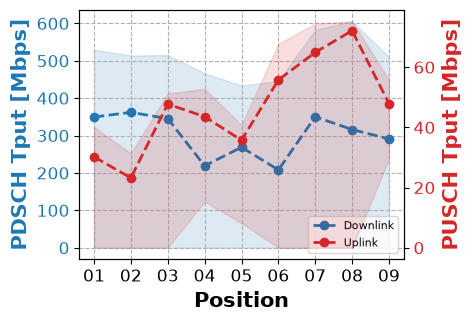

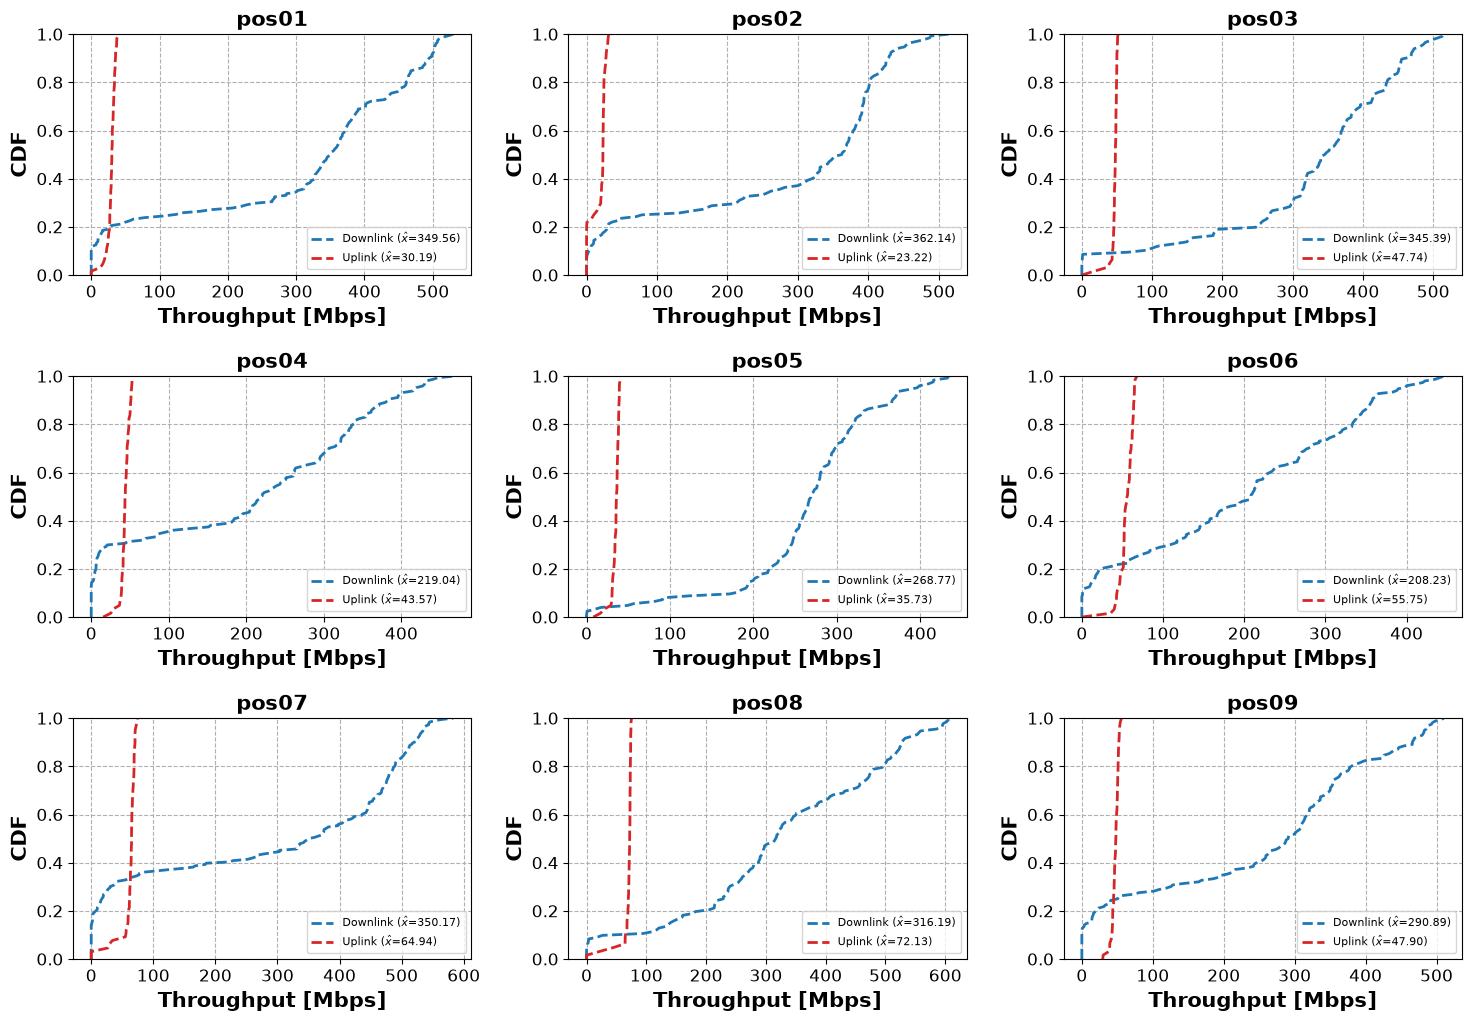

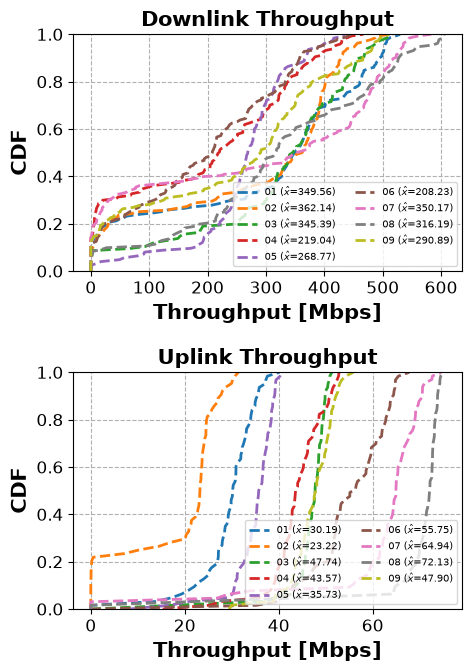

In [46]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9pm_arfcnLock_pos07',
    'pos08': '20260804_VzwLegends9pm_arfcnLock_pos08',
    'pos09': '20260804_VzwLegends9pm_arfcnLock_pos09'
}

test_configurations = {
    'Downlink': {
        'DataFrame': nrPdsch,
        'Test Name': 'Capacity',
        'Direction': 'Downlink',
        'Column': '5G NR Net PDSCH Throughput',
        'Color': 'tab:blue'
    },
    'Uplink': {
        'DataFrame': nrPusch,
        'Test Name': 'Capacity',
        'Direction': 'Uplink',
        'Column': '5G NR Net PUSCH Throughput',
        'Color': 'tab:red'
    }
}

positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))




fig, ax = plt.subplots(figsize=(5, 3.5))
ax2 = ax.twinx()

for test_label, test_configuration in test_configurations.items():
    median_values = []
    minimum_values = []
    maximum_values = []

    for position, collection in position_collections.items():
        mask = (
                (test_configuration['DataFrame']['Collection'] == collection) &
                (test_configuration['DataFrame']['Test Name'] == test_configuration['Test Name']) &
                (test_configuration['DataFrame']['Direction'] == test_configuration['Direction']) &
                (test_configuration['DataFrame']['Test Status'] == 'Completed')
        )

        throughput_column = test_configuration['Column']
        df_temp = test_configuration['DataFrame'].loc[mask, throughput_column].dropna() / 1e3

        median_values.append(df_temp.median())
        minimum_values.append(df_temp.min())
        maximum_values.append(df_temp.max())

    median_values = np.array(median_values)
    minimum_values = np.array(minimum_values)
    maximum_values = np.array(maximum_values)
    plot_axis = ax if test_label == 'Downlink' else ax2

    plot_axis.fill_between(
        x_positions, minimum_values, maximum_values,
        color=test_configuration['Color'], alpha=0.15
    )

    plot_axis.plot(
        x_positions, median_values,
        label=test_label, marker='o', markersize=6,
        linewidth=2, linestyle="dashed", color=test_configuration['Color']
    )

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("PDSCH Tput [Mbps]", fontsize=15, fontweight="bold", color="tab:blue")
ax2.set_ylabel("PUSCH Tput [Mbps]", fontsize=15, fontweight="bold", color="tab:red")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.yaxis.set_minor_locator(AutoLocator())
ax2.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelsize=12, labelcolor="tab:red")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    for test_label, test_configuration in test_configurations.items():
        mask = (
                (test_configuration['DataFrame']['Collection'] == collection) &
                (test_configuration['DataFrame']['Test Name'] == test_configuration['Test Name']) &
                (test_configuration['DataFrame']['Direction'] == test_configuration['Direction']) &
                (test_configuration['DataFrame']['Test Status'] == 'Completed')
        )

        throughput_column = test_configuration['Column']
        df_temp = (test_configuration['DataFrame'].loc[mask, throughput_column].dropna() / 1e3).sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{test_label} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed", color=test_configuration['Color']
        )

    ax.set_title(position, fontsize=15, fontweight="bold")
    ax.set_xlabel("Throughput [Mbps]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()






fig, axes = plt.subplots(2, 1, figsize=(5, 7))
position_colors = plt.cm.tab10.colors

for ax, (test_label, test_configuration) in zip(axes, test_configurations.items()):
    for index, (position, collection) in enumerate(position_collections.items()):
        mask = (
                (test_configuration['DataFrame']['Collection'] == collection) &
                (test_configuration['DataFrame']['Test Name'] == test_configuration['Test Name']) &
                (test_configuration['DataFrame']['Direction'] == test_configuration['Direction']) &
                (test_configuration['DataFrame']['Test Status'] == 'Completed')
        )

        throughput_column = test_configuration['Column']
        df_temp = (test_configuration['DataFrame'].loc[mask, throughput_column].dropna() / 1e3).sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{position.replace('pos', '')} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed", color=position_colors[index]
        )

    ax.set_title(f"{test_label} Throughput", fontsize=15, fontweight="bold")
    ax.set_xlabel("Throughput [Mbps]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=7, loc="lower right", ncol=2)

plt.tight_layout()
plt.show()


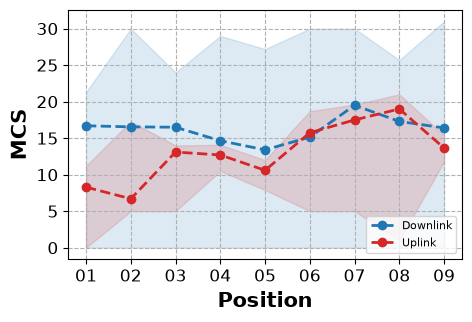

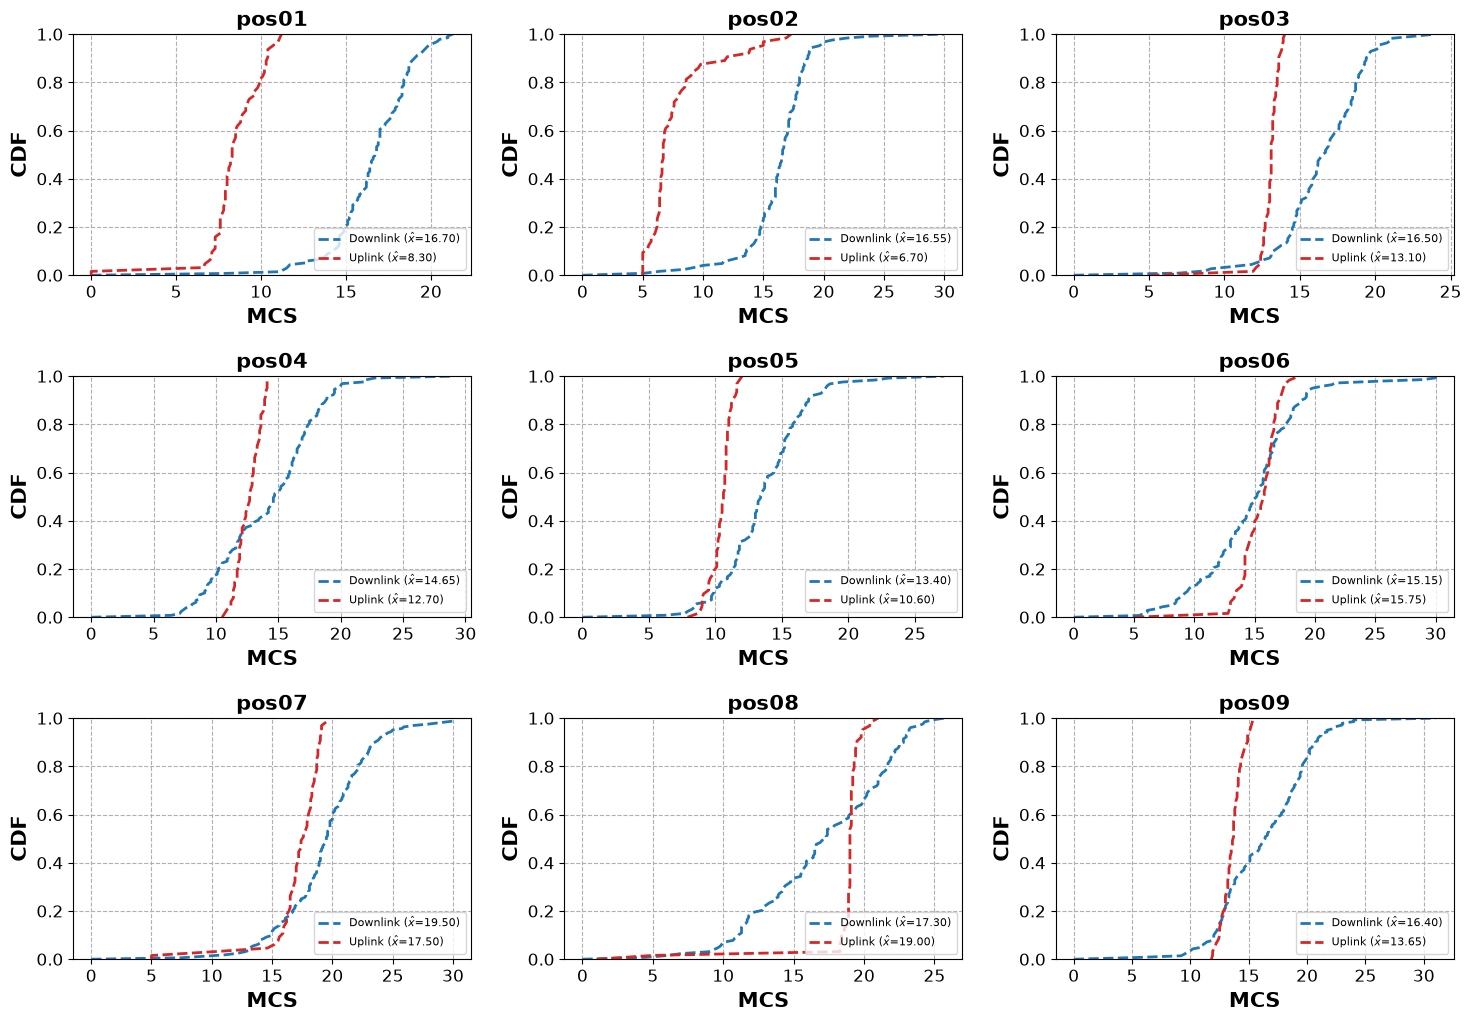

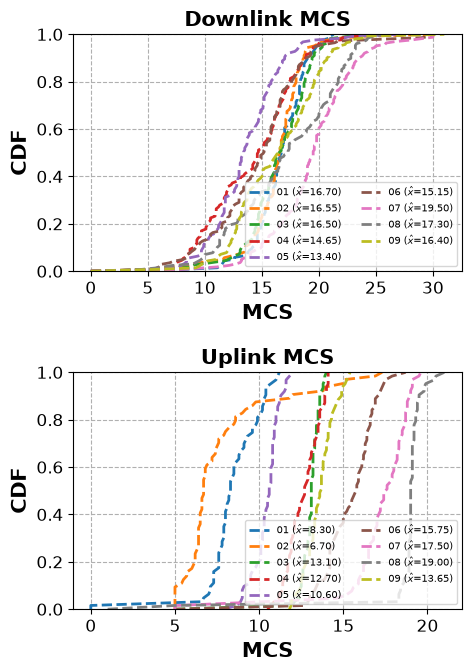

In [50]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9pm_arfcnLock_pos07',
    'pos08': '20260804_VzwLegends9pm_arfcnLock_pos08',
    'pos09': '20260804_VzwLegends9pm_arfcnLock_pos09'
}

test_configurations = {
    'Downlink': {
        'DataFrame': nrPdsch,
        'Test Name': 'Capacity',
        'Direction': 'Downlink',
        'Column': 'MCS',
        'Color': 'tab:blue'
    },
    'Uplink': {
        'DataFrame': nrPusch,
        'Test Name': 'Capacity',
        'Direction': 'Uplink',
        'Column': 'MCS',
        'Color': 'tab:red'
    }
}

positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))




fig, ax = plt.subplots(figsize=(5, 3.5))

for test_label, test_configuration in test_configurations.items():
    median_values = []
    minimum_values = []
    maximum_values = []

    for position, collection in position_collections.items():
        mask = (
                (test_configuration['DataFrame']['Collection'] == collection) &
                (test_configuration['DataFrame']['Test Name'] == test_configuration['Test Name']) &
                (test_configuration['DataFrame']['Direction'] == test_configuration['Direction']) &
                (test_configuration['DataFrame']['Test Status'] == 'Completed')
        )

        throughput_column = test_configuration['Column']
        df_temp = test_configuration['DataFrame'].loc[mask, throughput_column].dropna()

        median_values.append(df_temp.median())
        minimum_values.append(df_temp.min())
        maximum_values.append(df_temp.max())

    median_values = np.array(median_values)
    minimum_values = np.array(minimum_values)
    maximum_values = np.array(maximum_values)

    ax.fill_between(
        x_positions, minimum_values, maximum_values,
        color=test_configuration['Color'], alpha=0.15
    )

    ax.plot(
        x_positions, median_values,
        label=test_label, marker='o', markersize=6,
        linewidth=2, linestyle="dashed", color=test_configuration['Color']
    )

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("MCS", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    for test_label, test_configuration in test_configurations.items():
        mask = (
                (test_configuration['DataFrame']['Collection'] == collection) &
                (test_configuration['DataFrame']['Test Name'] == test_configuration['Test Name']) &
                (test_configuration['DataFrame']['Direction'] == test_configuration['Direction']) &
                (test_configuration['DataFrame']['Test Status'] == 'Completed')
        )

        throughput_column = test_configuration['Column']
        df_temp = (test_configuration['DataFrame'].loc[mask, throughput_column].dropna()).sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{test_label} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed", color=test_configuration['Color']
        )

    ax.set_title(position, fontsize=15, fontweight="bold")
    ax.set_xlabel("MCS", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()






fig, axes = plt.subplots(2, 1, figsize=(5, 7))
position_colors = plt.cm.tab10.colors

for ax, (test_label, test_configuration) in zip(axes, test_configurations.items()):
    for index, (position, collection) in enumerate(position_collections.items()):
        mask = (
                (test_configuration['DataFrame']['Collection'] == collection) &
                (test_configuration['DataFrame']['Test Name'] == test_configuration['Test Name']) &
                (test_configuration['DataFrame']['Direction'] == test_configuration['Direction']) &
                (test_configuration['DataFrame']['Test Status'] == 'Completed')
        )

        throughput_column = test_configuration['Column']
        df_temp = (test_configuration['DataFrame'].loc[mask, throughput_column].dropna()).sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{position.replace('pos', '')} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed", color=position_colors[index]
        )

    ax.set_title(f"{test_label} MCS", fontsize=15, fontweight="bold")
    ax.set_xlabel("MCS", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=7, loc="lower right", ncol=2)

plt.tight_layout()
plt.show()


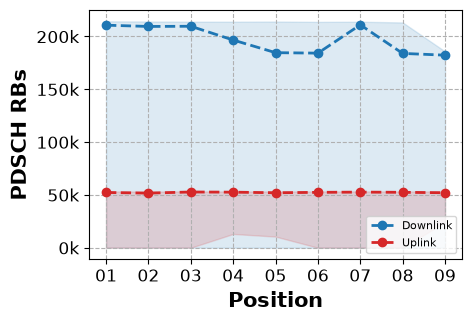

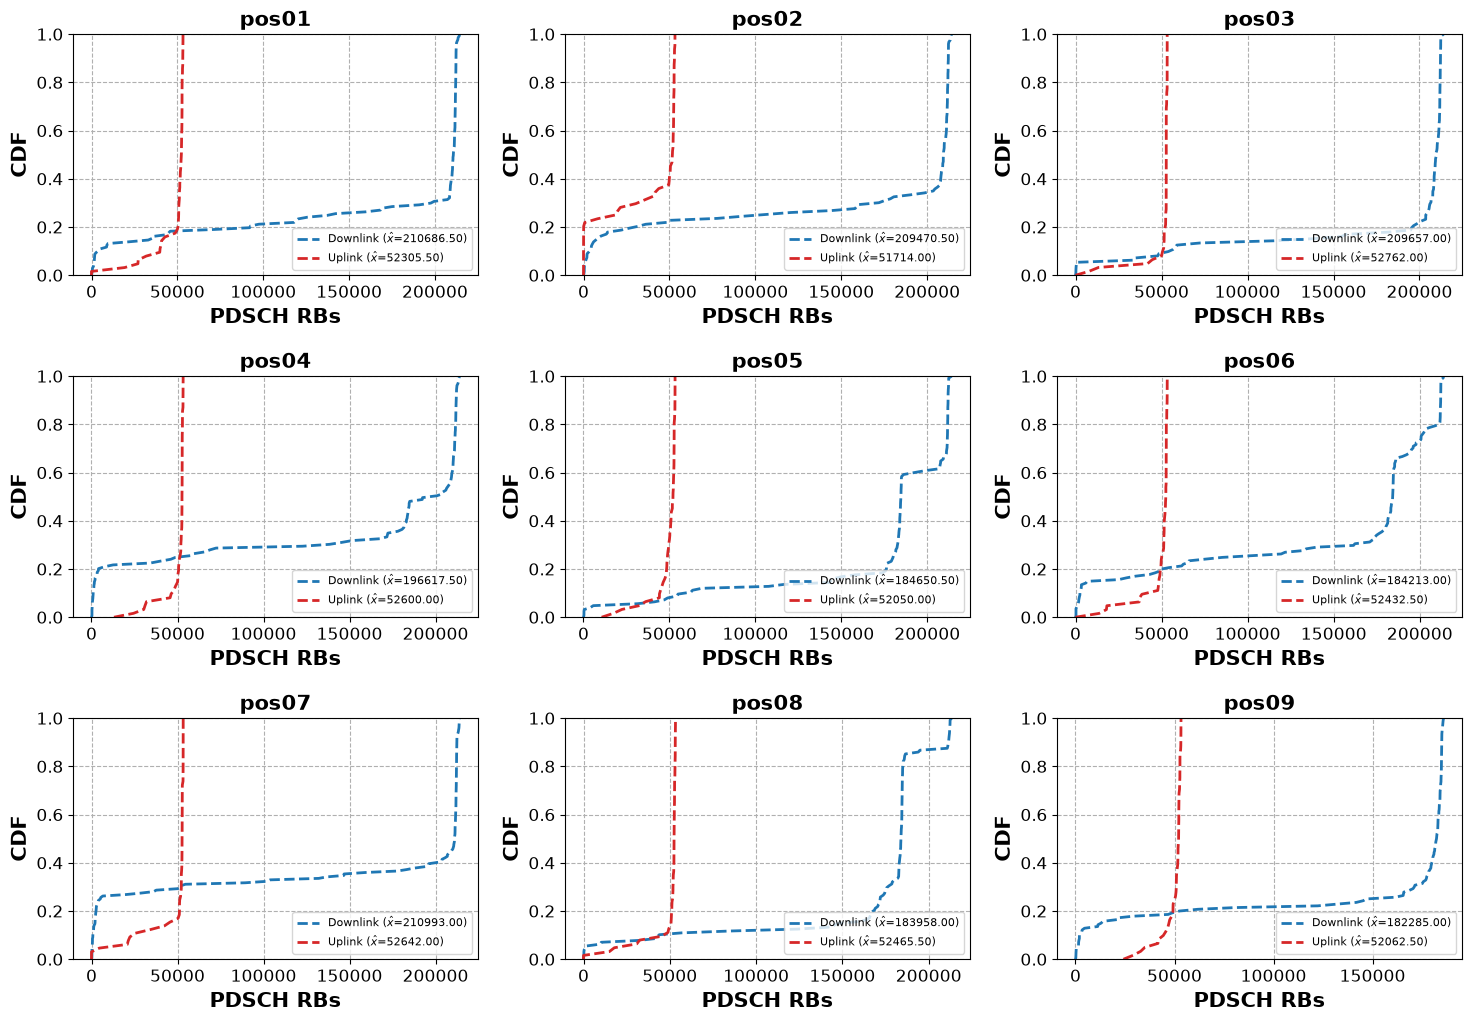

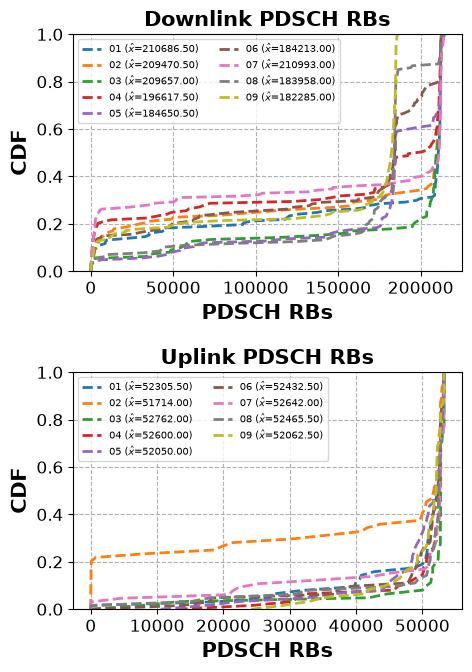

In [55]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9pm_arfcnLock_pos07',
    'pos08': '20260804_VzwLegends9pm_arfcnLock_pos08',
    'pos09': '20260804_VzwLegends9pm_arfcnLock_pos09'
}

test_configurations = {
    'Downlink': {
        'DataFrame': nrPdsch,
        'Test Name': 'Capacity',
        'Direction': 'Downlink',
        'Column': 'PDSCH RBs',
        'Color': 'tab:blue'
    },
    'Uplink': {
        'DataFrame': nrPusch,
        'Test Name': 'Capacity',
        'Direction': 'Uplink',
        'Column': 'PUSCH RBs',
        'Color': 'tab:red'
    }
}

positions = [position.replace('pos', '') for position in position_collections.keys()]
x_positions = np.arange(len(positions))




fig, ax = plt.subplots(figsize=(5, 3.5))

for test_label, test_configuration in test_configurations.items():
    median_values = []
    minimum_values = []
    maximum_values = []

    for position, collection in position_collections.items():
        mask = (
                (test_configuration['DataFrame']['Collection'] == collection) &
                (test_configuration['DataFrame']['Test Name'] == test_configuration['Test Name']) &
                (test_configuration['DataFrame']['Direction'] == test_configuration['Direction']) &
                (test_configuration['DataFrame']['Test Status'] == 'Completed')
        )

        throughput_column = test_configuration['Column']
        df_temp = test_configuration['DataFrame'].loc[mask, throughput_column].dropna()

        median_values.append(df_temp.median())
        minimum_values.append(df_temp.min())
        maximum_values.append(df_temp.max())

    median_values = np.array(median_values)
    minimum_values = np.array(minimum_values)
    maximum_values = np.array(maximum_values)

    ax.fill_between(
        x_positions, minimum_values, maximum_values,
        color=test_configuration['Color'], alpha=0.15
    )

    ax.plot(
        x_positions, median_values,
        label=test_label, marker='o', markersize=6,
        linewidth=2, linestyle="dashed", color=test_configuration['Color']
    )

ax.set_xlabel("Position", fontsize=15, fontweight="bold")
ax.set_ylabel("PDSCH RBs", fontsize=15, fontweight="bold")
ax.set_xticks(x_positions)
ax.set_xticklabels(positions)
ax.yaxis.set_major_formatter(lambda value, position: f"{value / 1000:g}k")
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (position, collection) in zip(axes, position_collections.items()):
    for test_label, test_configuration in test_configurations.items():
        mask = (
                (test_configuration['DataFrame']['Collection'] == collection) &
                (test_configuration['DataFrame']['Test Name'] == test_configuration['Test Name']) &
                (test_configuration['DataFrame']['Direction'] == test_configuration['Direction']) &
                (test_configuration['DataFrame']['Test Status'] == 'Completed')
        )

        throughput_column = test_configuration['Column']
        df_temp = (test_configuration['DataFrame'].loc[mask, throughput_column].dropna()).sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{test_label} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed", color=test_configuration['Color']
        )

    ax.set_title(position, fontsize=15, fontweight="bold")
    ax.set_xlabel("PDSCH RBs", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()






fig, axes = plt.subplots(2, 1, figsize=(5, 7))
position_colors = plt.cm.tab10.colors

for ax, (test_label, test_configuration) in zip(axes, test_configurations.items()):
    for index, (position, collection) in enumerate(position_collections.items()):
        mask = (
                (test_configuration['DataFrame']['Collection'] == collection) &
                (test_configuration['DataFrame']['Test Name'] == test_configuration['Test Name']) &
                (test_configuration['DataFrame']['Direction'] == test_configuration['Direction']) &
                (test_configuration['DataFrame']['Test Status'] == 'Completed')
        )

        throughput_column = test_configuration['Column']
        df_temp = (test_configuration['DataFrame'].loc[mask, throughput_column].dropna()).sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{position.replace('pos', '')} ($\hat{{x}}$={df_temp.median():.2f})",
            linewidth=2, linestyle="dashed", color=position_colors[index]
        )

    ax.set_title(f"{test_label} PDSCH RBs", fontsize=15, fontweight="bold")
    ax.set_xlabel("PDSCH RBs", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=7, loc="upper left", ncol=2)

plt.tight_layout()
plt.show()


In [51]:
nrPdsch.columns

Index(['Time', 'Database', 'Collection', 'Latitude', 'Longitude', 'Operator',
       'Serial Number', 'Model', 'RAN Configuration', 'Band Number',
       'PCI 5G NR', 'SSB Index', 'DL NR-ARFCN', 'DL Center Frequency',
       'DL Point A Frequency', 'DL Subcarrier Spacing', 'DL Bandwidth',
       'DL Bandwidth Aggregated', 'Cell Type', 'Max PDSCH Layers',
       'Avg PDSCH Layers', 'PDSCH SCS', 'Enabled256QAM',
       '5G NR Net PDSCH Throughput', 'PDSCH BLER', 'PDSCH Avg RBs per Slot',
       'PDSCH RBs', 'Num PDSCH REs', 'MCS', 'Avg PDSCH Code Rate',
       'PDSCH Used Slots', 'Bytes Transferred over PDSCH', 'PDSCH SINR',
       'PDSCH Available Slots', 'PDSCH Slot Utilization',
       'PDSCH Avg RBs all Slots', 'Total Frames', '1 Layer Count',
       '2 Layers Count', '3 Layers Count', '4 Layers Count', '5 Layers Count',
       '6 Layers Count', '7 Layers Count', '8 Layers Count', 'Num Slots',
       'Slot Pattern', 'Num Patterns', 'Pattern1 Periodicity',
       'Pattern1 DL Slots', 

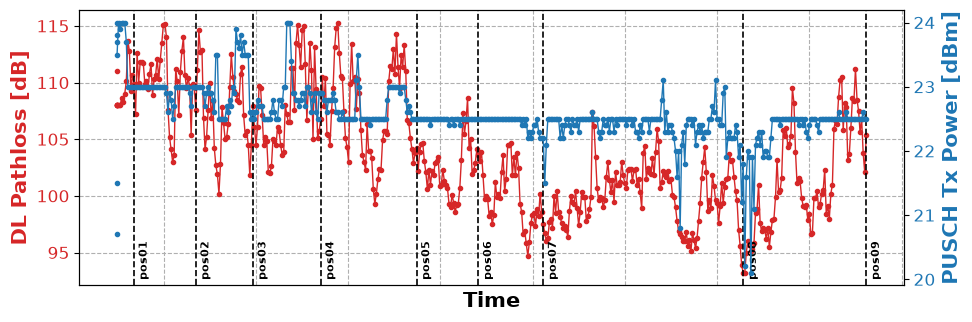

In [24]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9pm_arfcnLock_pos07',
    'pos08': '20260804_VzwLegends9pm_arfcnLock_pos08',
    'pos09': '20260804_VzwLegends9pm_arfcnLock_pos09'
}

position_mask = (
        nrPusch['Collection'].isin(position_collections.values())
)

df_position = nrPusch.loc[position_mask, ['Collection', 'Latitude', 'Longitude']].dropna().copy()

collection_to_position = {
    collection: position for position, collection in position_collections.items()
}

df_position['Position'] = df_position['Collection'].map(collection_to_position)

position_average = df_position.groupby('Position')[['Latitude', 'Longitude']].mean().reset_index()

mask = (
        nrPusch['Collection'] == '20260804_VzwLegends9pm_arfcnLock_walkPos01-09'
)

df_temp = nrPusch.loc[
    mask, ['Time', 'Latitude', 'Longitude', 'DL Pathloss', 'PUSCH Tx Power']
].dropna(subset=['Time', 'Latitude', 'Longitude']).sort_values('Time')

position_times = []

for _, position_row in position_average.iterrows():
    distance = (
        (df_temp['Latitude'] - position_row['Latitude']).abs()
        + (df_temp['Longitude'] - position_row['Longitude']).abs()
    )

    closest_index = distance.idxmin()

    position_times.append({
        'Position': position_row['Position'],
        'Time': df_temp.loc[closest_index, 'Time'],
        'DL Pathloss': df_temp.loc[closest_index, 'DL Pathloss'],
        'PUSCH Tx Power': df_temp.loc[closest_index, 'PUSCH Tx Power'],
        'Latitude': df_temp.loc[closest_index, 'Latitude'],
        'Longitude': df_temp.loc[closest_index, 'Longitude']
    })

position_times = pd.DataFrame(position_times)

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    df_temp['Time'], df_temp['DL Pathloss'],
    label=rf"(DL Pathloss $\hat{{x}}$={df_temp['DL Pathloss'].median():.2f})",
    marker='.', linewidth=1, linestyle="solid", color="tab:red"
)

ax2 = ax.twinx()
ax2.plot(
    df_temp['Time'], df_temp['PUSCH Tx Power'],
    label=rf"(PUSCH Tx Power $\hat{{x}}$={df_temp['PUSCH Tx Power'].median():.2f})",
    marker='.', linewidth=1, linestyle="solid", color="tab:blue"
)

for _, position_row in position_times.iterrows():
    ax.axvline(
        x=position_row['Time'],
        linewidth=1.2, linestyle="dashed", color="black", zorder=5
    )
    ax.annotate(
        position_row['Position'],
        xy=(position_row['Time'], 0.02),
        xytext=(3, 0), textcoords="offset points",
        xycoords=("data", "axes fraction"),
        ha="left", va="bottom", fontsize=8, fontweight="bold", rotation=90
    )

# ax.set_title("Point A", fontsize=15, fontweight="bold")
ax.set_xlabel("Time", fontsize=15, fontweight="bold")
ax.set_ylabel("DL Pathloss [dB]", fontsize=15, fontweight="bold", color="tab:red")
ax2.set_ylabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold", color="tab:blue")
ax.yaxis.set_minor_locator(AutoLocator())
ax2.yaxis.set_minor_locator(AutoLocator())
# plt.xlim(22, 24)
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="y", labelsize=12, labelcolor="tab:red")
ax2.tick_params(axis="y", labelsize=12, labelcolor="tab:blue")
plt.xticks(fontsize=12)

ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False) # hide x-axis values

# lines1, labels1 = ax.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

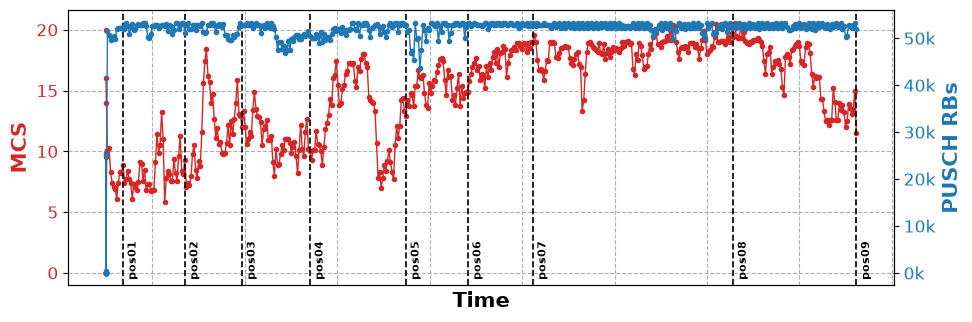

In [25]:
plt.rcParams["text.usetex"] = False

position_collections = {
    'pos01': '20260804_VzwLegends9pm_arfcnLock_pos01',
    'pos02': '20260804_VzwLegends9pm_arfcnLock_pos02',
    'pos03': '20260804_VzwLegends9pm_arfcnLock_pos03',
    'pos04': '20260804_VzwLegends9pm_arfcnLock_pos04',
    'pos05': '20260804_VzwLegends9pm_arfcnLock_pos05',
    'pos06': '20260804_VzwLegends9pm_arfcnLock_pos06',
    'pos07': '20260804_VzwLegends9pm_arfcnLock_pos07',
    'pos08': '20260804_VzwLegends9pm_arfcnLock_pos08',
    'pos09': '20260804_VzwLegends9pm_arfcnLock_pos09'
}

position_mask = (
        nrPusch['Collection'].isin(position_collections.values())
)

df_position = nrPusch.loc[position_mask, ['Collection', 'Latitude', 'Longitude']].dropna().copy()

collection_to_position = {
    collection: position for position, collection in position_collections.items()
}

df_position['Position'] = df_position['Collection'].map(collection_to_position)

position_average = df_position.groupby('Position')[['Latitude', 'Longitude']].mean().reset_index()

mask = (
        nrPusch['Collection'] == '20260804_VzwLegends9pm_arfcnLock_walkPos01-09'
)

df_temp = nrPusch.loc[
    mask, ['Time', 'Latitude', 'Longitude', 'MCS', 'PUSCH RBs']
].dropna(subset=['Time', 'Latitude', 'Longitude']).sort_values('Time')

position_times = []

for _, position_row in position_average.iterrows():
    distance = (
        (df_temp['Latitude'] - position_row['Latitude']).abs()
        + (df_temp['Longitude'] - position_row['Longitude']).abs()
    )

    closest_index = distance.idxmin()

    position_times.append({
        'Position': position_row['Position'],
        'Time': df_temp.loc[closest_index, 'Time'],
        'MCS': df_temp.loc[closest_index, 'MCS'],
        'PUSCH RBs': df_temp.loc[closest_index, 'PUSCH RBs'],
        'Latitude': df_temp.loc[closest_index, 'Latitude'],
        'Longitude': df_temp.loc[closest_index, 'Longitude']
    })

position_times = pd.DataFrame(position_times)

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    df_temp['Time'], df_temp['MCS'],
    label=rf"(MCS $\hat{{x}}$={df_temp['MCS'].median():.2f})",
    marker='.', linewidth=1, linestyle="solid", color="tab:red"
)

ax2 = ax.twinx()
ax2.plot(
    df_temp['Time'], df_temp['PUSCH RBs'],
    label=rf"(PUSCH RBs $\hat{{x}}$={df_temp['PUSCH RBs'].median() / 1000:.2f}k)",
    marker='.', linewidth=1, linestyle="solid", color="tab:blue"
)

for _, position_row in position_times.iterrows():
    ax.axvline(
        x=position_row['Time'],
        linewidth=1.2, linestyle="dashed", color="black", zorder=5
    )
    ax.annotate(
        position_row['Position'],
        xy=(position_row['Time'], 0.02),
        xytext=(3, 0), textcoords="offset points",
        xycoords=("data", "axes fraction"),
        ha="left", va="bottom", fontsize=8, fontweight="bold", rotation=90
    )

# ax.set_title("Point A", fontsize=15, fontweight="bold")
ax.set_xlabel("Time", fontsize=15, fontweight="bold")
ax.set_ylabel("MCS", fontsize=15, fontweight="bold", color="tab:red")
ax2.set_ylabel("PUSCH RBs", fontsize=15, fontweight="bold", color="tab:blue")
ax.yaxis.set_minor_locator(AutoLocator())
ax2.yaxis.set_major_formatter(lambda value, position: f"{value / 1000:g}k")
# plt.xlim(22, 24)
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="y", labelsize=12, labelcolor="tab:red")
ax2.tick_params(axis="y", labelsize=12, labelcolor="tab:blue")
plt.xticks(fontsize=12)

ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False) # hide x-axis values

# lines1, labels1 = ax.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

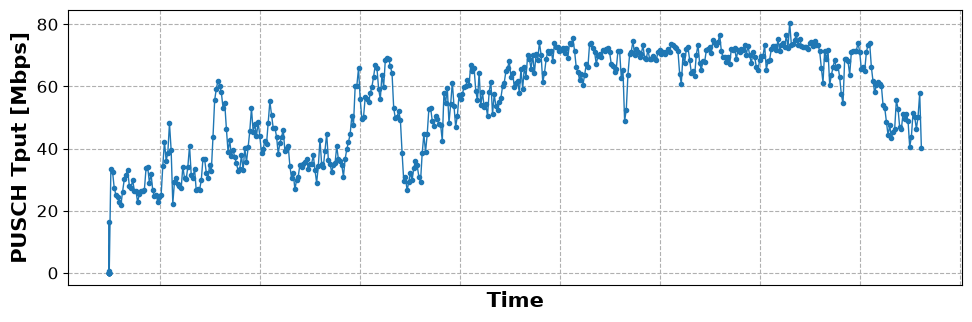

In [26]:
plt.rcParams["text.usetex"] = False

mask = (
        nrPusch['Collection'] == '20260804_VzwLegends9pm_arfcnLock_walkPos01-09'
)

df_temp = nrPusch.loc[
    mask, ['Time', '5G NR Net PUSCH Throughput']
].dropna().sort_values('Time')

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    df_temp['Time'], df_temp['5G NR Net PUSCH Throughput'] / 1e3,
    marker='.', linewidth=1, linestyle="solid", color="tab:blue"
)

ax.set_xlabel("Time", fontsize=15, fontweight="bold")
ax.set_ylabel("PUSCH Tput [Mbps]", fontsize=15, fontweight="bold")
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()

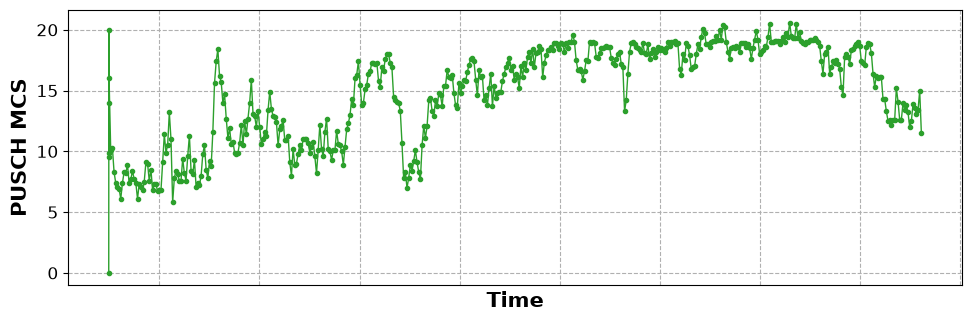

In [27]:
plt.rcParams["text.usetex"] = False

mask = (
        nrPusch['Collection'] == '20260804_VzwLegends9pm_arfcnLock_walkPos01-09'
)

df_temp = nrPusch.loc[
    mask, ['Time', 'MCS']
].dropna().sort_values('Time')

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    df_temp['Time'], df_temp['MCS'],
    marker='.', linewidth=1, linestyle="solid", color="tab:green"
)

ax.set_xlabel("Time", fontsize=15, fontweight="bold")
ax.set_ylabel("PUSCH MCS", fontsize=15, fontweight="bold")
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()

In [28]:
nrPusch.columns

Index(['Time', 'Database', 'Collection', 'Latitude', 'Longitude', 'Operator',
       'Serial Number', 'Model', 'RAN Configuration', 'Band Number',
       'PCI 5G NR', 'SSB Index', 'UL NR-ARFCN', 'UL Point A Frequency',
       'UL Subcarrier Spacing', 'UL Bandwidth', 'UL Bandwidth Aggregated',
       'Cell Type', 'Max PUSCH Layers', 'Avg PUSCH Layers', 'PUSCH SCS',
       'Enabled256QAM', '5G NR Net PUSCH Throughput', 'PUSCH Avg RBs per Slot',
       'PUSCH RBs', 'MCS', 'PUSCH Used Slots', 'Bytes Transferred over PUSCH',
       'PUSCH Available Slots', 'PUSCH Slot Utilization',
       'PUSCH Avg RBs all Slots', 'PUSCH Tx Power', 'DL Pathloss',
       'PUSCH ReTx Rate', '1 Layer', '2 Layers', '3 Layers', '4 Layers',
       '5 Layers', '6 Layers', '7 Layers', '8 Layers', 'Num Slots',
       'Slot Pattern', 'Num Patterns', 'Pattern1 Periodicity',
       'Pattern1 UL Slots', 'Pattern1 UL Symbols', 'Pattern2 Periodicity',
       'Pattern2 UL Slots', 'Pattern2 UL Symbols', 'Num PUSCH TBs',
  

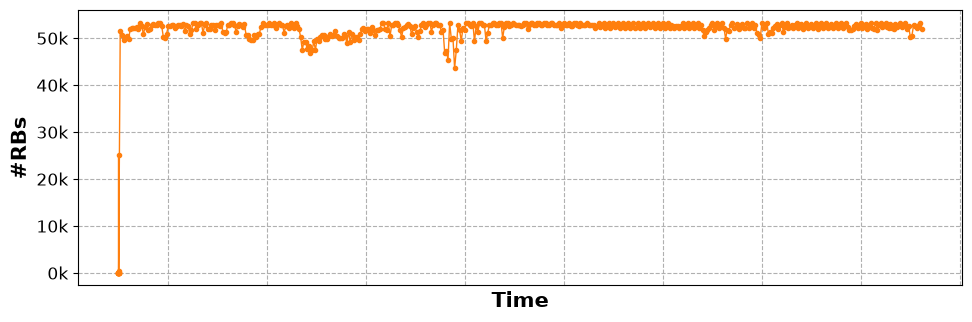

In [54]:
plt.rcParams["text.usetex"] = False

mask = (
        nrPusch['Collection'] == '20260804_VzwLegends9pm_arfcnLock_walkPos01-09'
)

df_temp = nrPusch.loc[
    mask, ['Time', 'PUSCH RBs']
].dropna().sort_values('Time')

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    df_temp['Time'], df_temp['PUSCH RBs'],
    marker='.', linewidth=1, linestyle="solid", color="tab:orange"
)

ax.set_xlabel("Time", fontsize=15, fontweight="bold")
ax.set_ylabel("#RBs", fontsize=15, fontweight="bold")
ax.yaxis.set_major_formatter(lambda value, position: f"{value / 1000:g}k")
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()

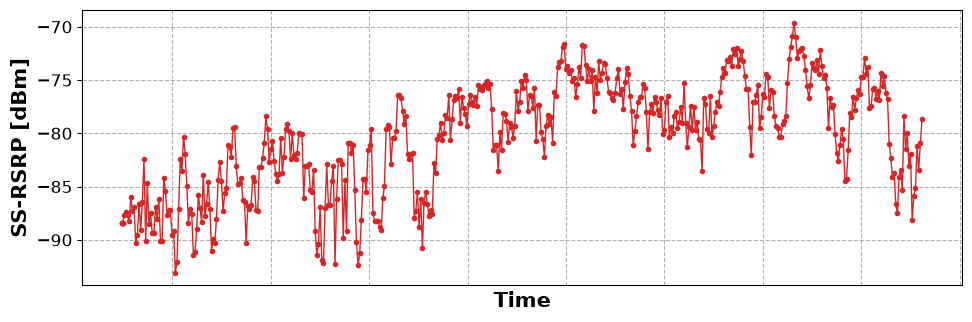

In [ ]:
plt.rcParams["text.usetex"] = False

collection = '20260804_VzwLegends9pm_arfcnLock_walkPos01-09'

pusch_mask = (nrPusch['Collection'] == collection)
radio_mask = (nrRadio['Collection'] == collection) & (nrRadio['Cell Type'] == 'MCG PCell')

df_pusch = nrPusch.loc[pusch_mask, ['Time']].dropna().drop_duplicates().sort_values('Time')
df_radio = nrRadio.loc[radio_mask, ['Time', 'SS-RSRP']].dropna().sort_values('Time')
df_matched = pd.merge_asof(df_pusch, df_radio, on='Time', direction='nearest').dropna()

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    df_matched['Time'], df_matched['SS-RSRP'],
    marker='.', linewidth=1, linestyle="solid", color="tab:red"
)

ax.set_xlabel("Time", fontsize=15, fontweight="bold")
ax.set_ylabel("SS-RSRP [dBm]", fontsize=15, fontweight="bold")
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()